# PIECEWISE PREDICTIONS

This notebook explores the effect of oscillating species on the accuracy of a linear approximation. The conclusion is that the effect is minimal.

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from src.timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery  # type: ignore
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Initializations

In [2]:
# Non-oscillating species timecourses
path = os.path.join(cn.DATA_DIR, f"find_oscillating_models.csv")
NONOSCILLATION_DF = pd.read_csv(path)
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_FREQUENCIES] == "[]"]
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_SPECIES_NAME] != cn.COL_AGGREGATION_TYPE_MODEL]
NONOSCILLATION_DF["key"] = [m + "_" + str(s) for m, s in zip(NONOSCILLATION_DF[cn.COL_SYSTEM_ID], NONOSCILLATION_DF[cn.COL_SPECIES_NAME])]
NONOSCILLATION_DF

,system_id,species_name,frequencies,endtime,key
17,BIOMD0000000042,GLC,[],300.0,BIOMD0000000042_GLC
19,BIOMD0000000042,FBP,[],300.0,BIOMD0000000042_FBP
20,BIOMD0000000042,GAP,[],300.0,BIOMD0000000042_GAP
21,BIOMD0000000042,NAD,[],300.0,BIOMD0000000042_NAD
22,BIOMD0000000042,NADH,[],300.0,BIOMD0000000042_NADH
...,...,...,...,...,...
4552,BIOMD0000001059,sursmac,[],7000.0,BIOMD0000001059_sursmac
4553,BIOMD0000001059,smacmit,[],7000.0,BIOMD0000001059_smacmit
4554,BIOMD0000001059,smac,[],7000.0,BIOMD0000001059_smac
4555,BIOMD0000001060,x1,[],40.0,BIOMD0000001060_x1


# Individual models

/Users/jlheller/home/Technical/repos/linearity_analysis/src/piecewise_system_discovery.py:890: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax_bot = plt.subplots(1, 1, figsize=figsize, sharex=True)


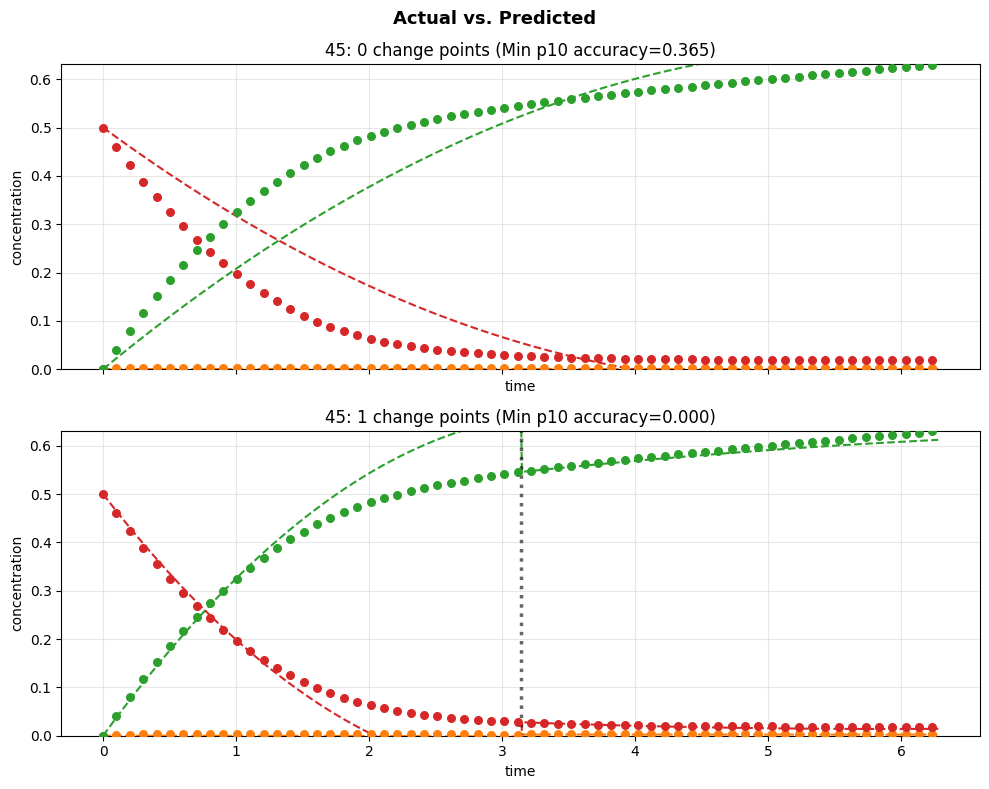

<Figure size 640x480 with 0 Axes>

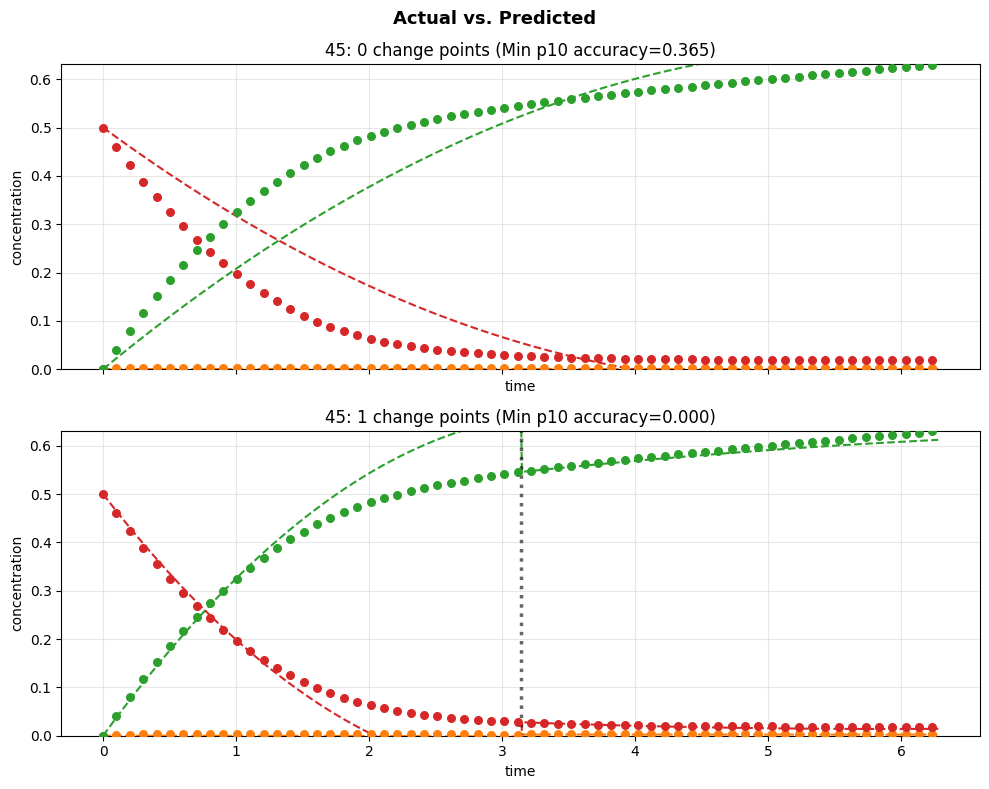

<Figure size 640x480 with 0 Axes>

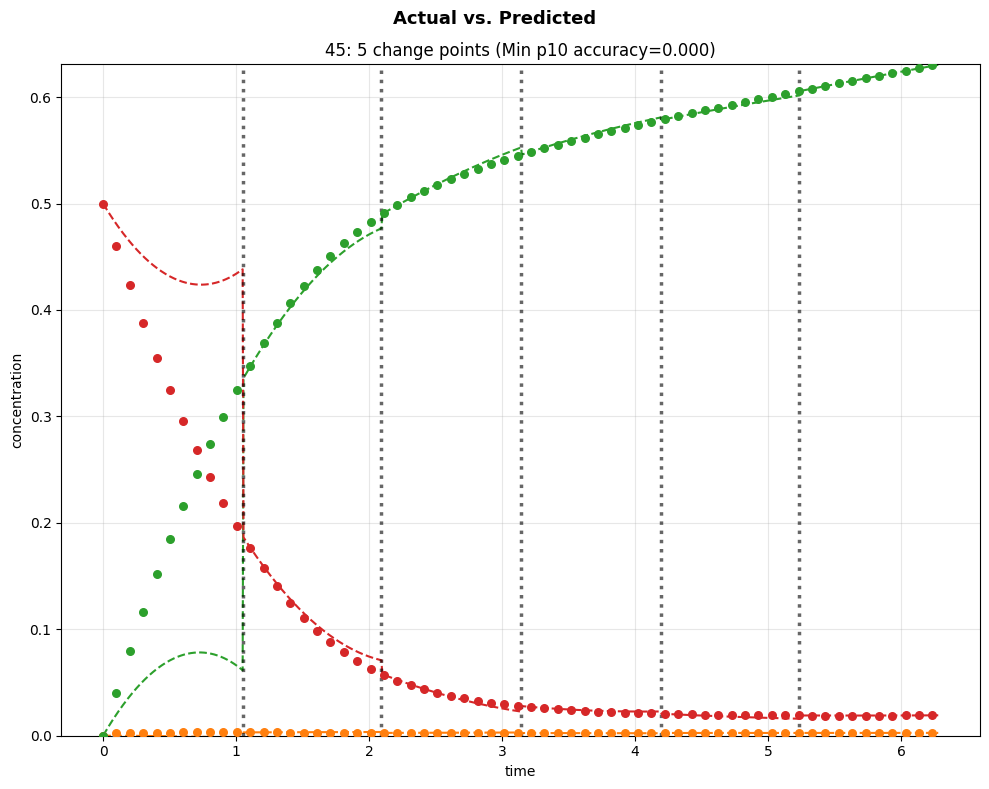

<Figure size 640x480 with 0 Axes>

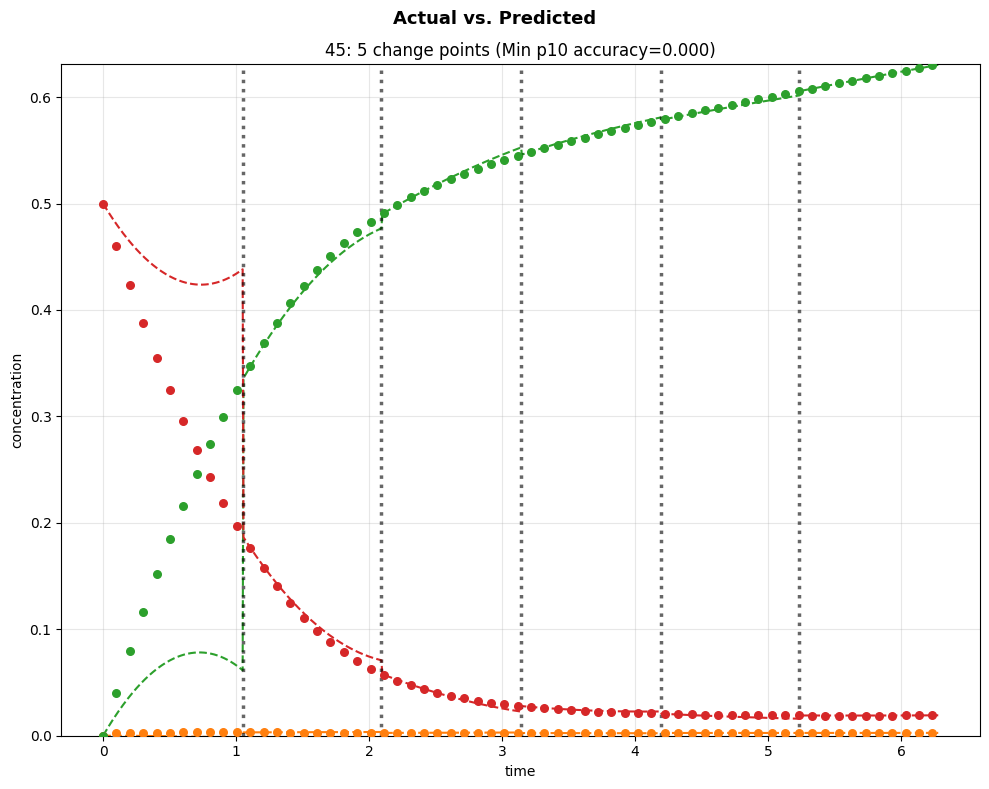

<Figure size 640x480 with 0 Axes>

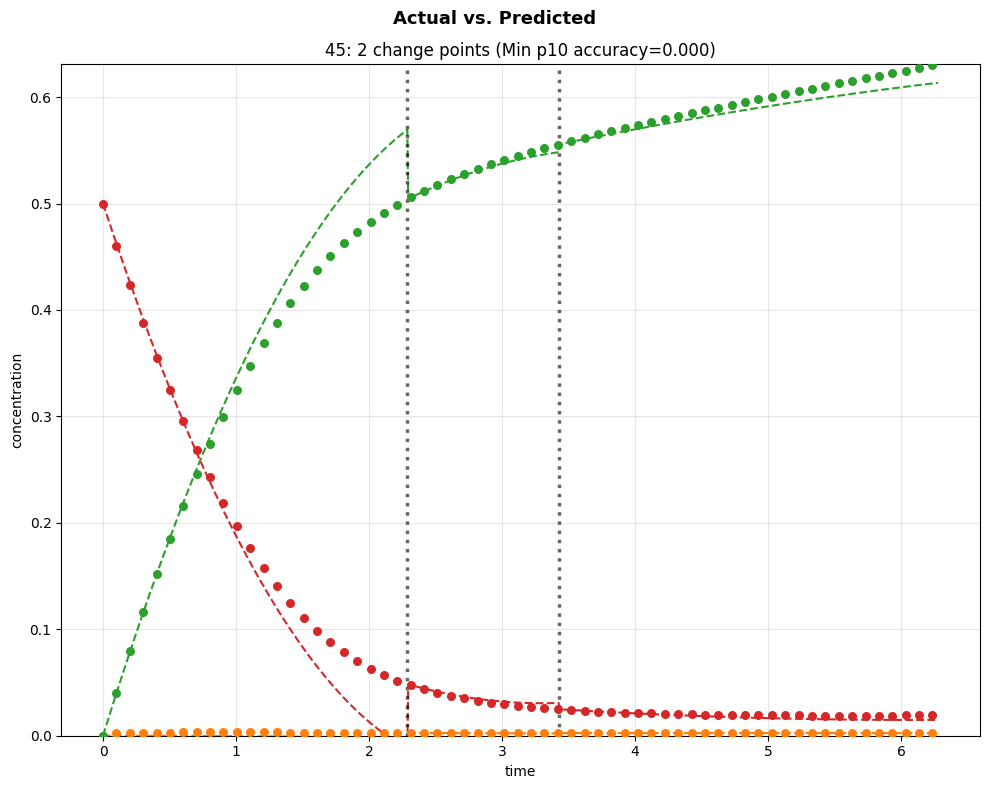

<Figure size 640x480 with 0 Axes>

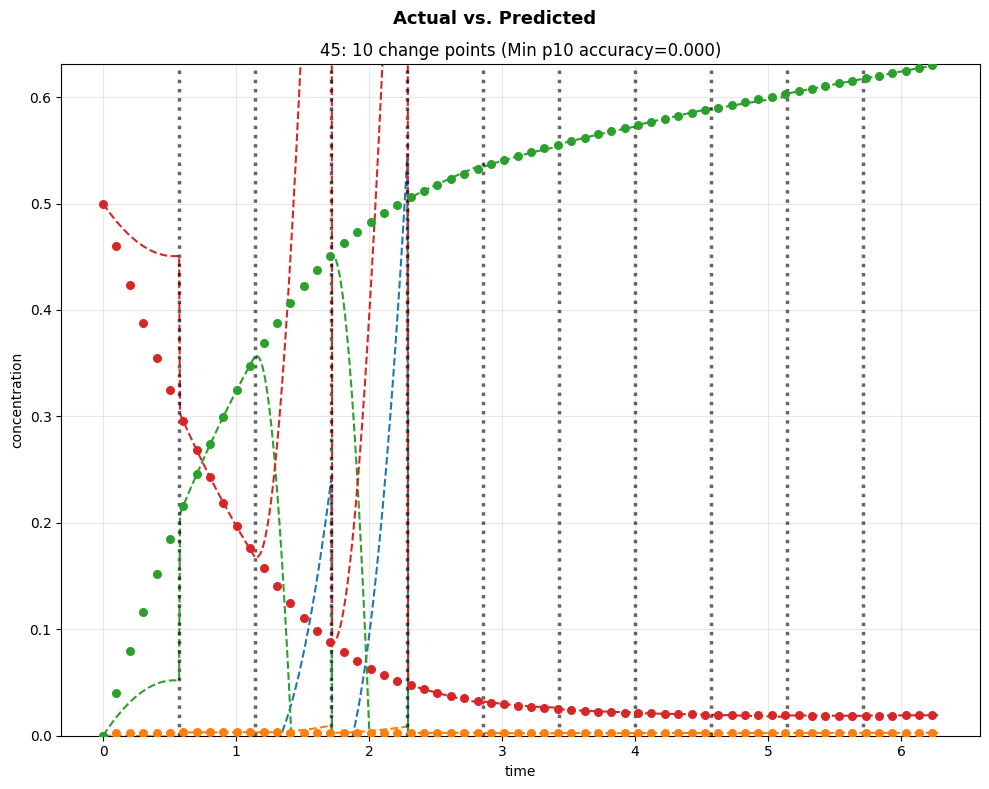

<Figure size 640x480 with 0 Axes>

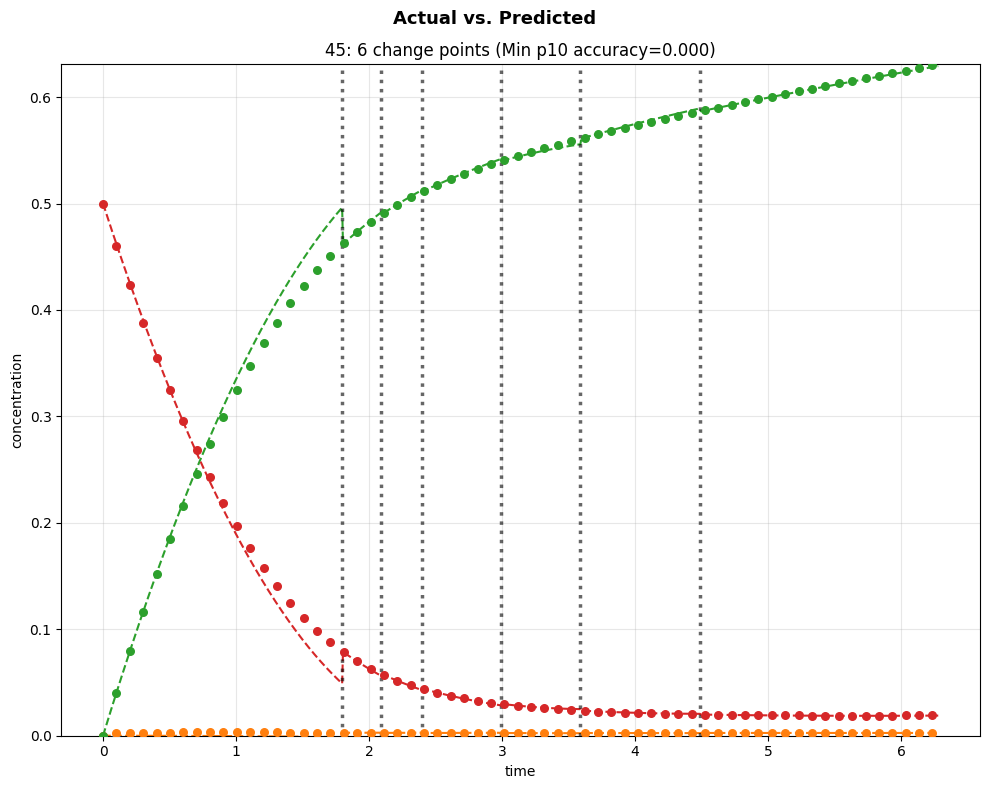

<Figure size 640x480 with 0 Axes>

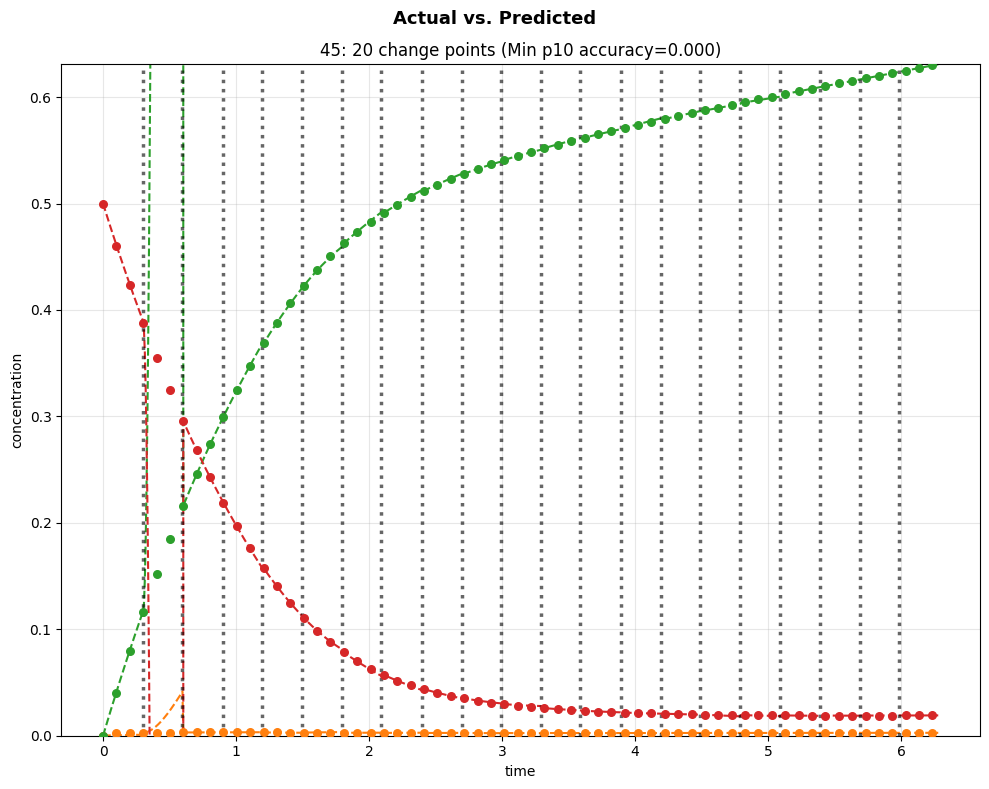

<Figure size 640x480 with 0 Axes>

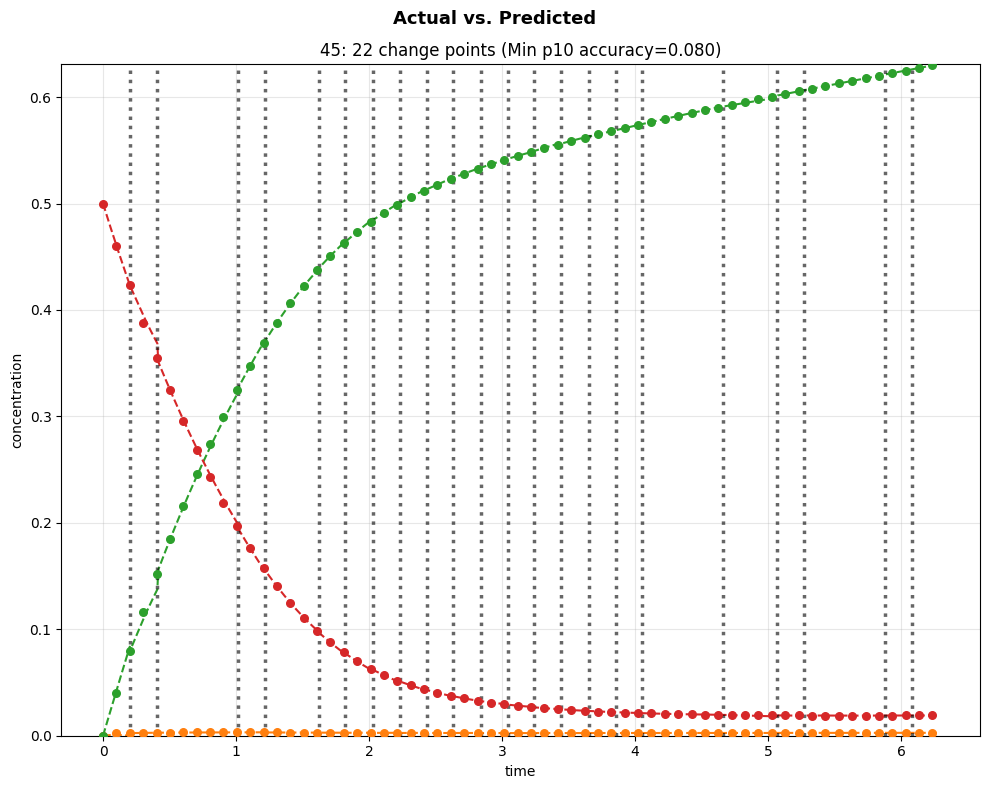

<Figure size 640x480 with 0 Axes>

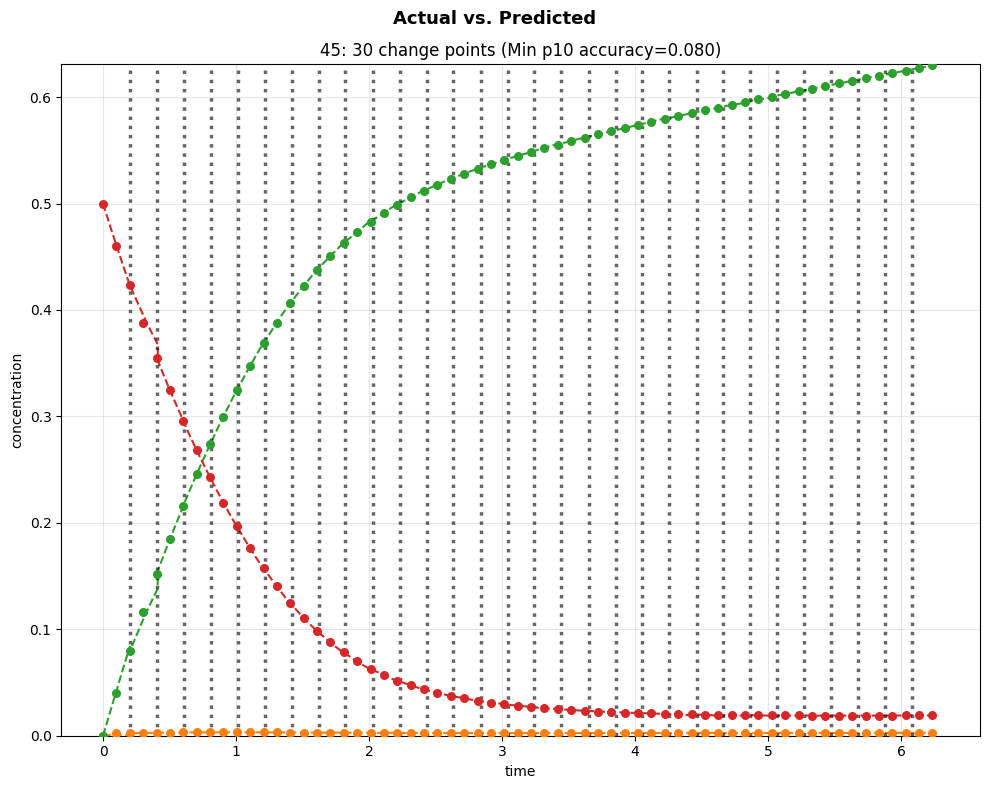

<Figure size 640x480 with 0 Axes>

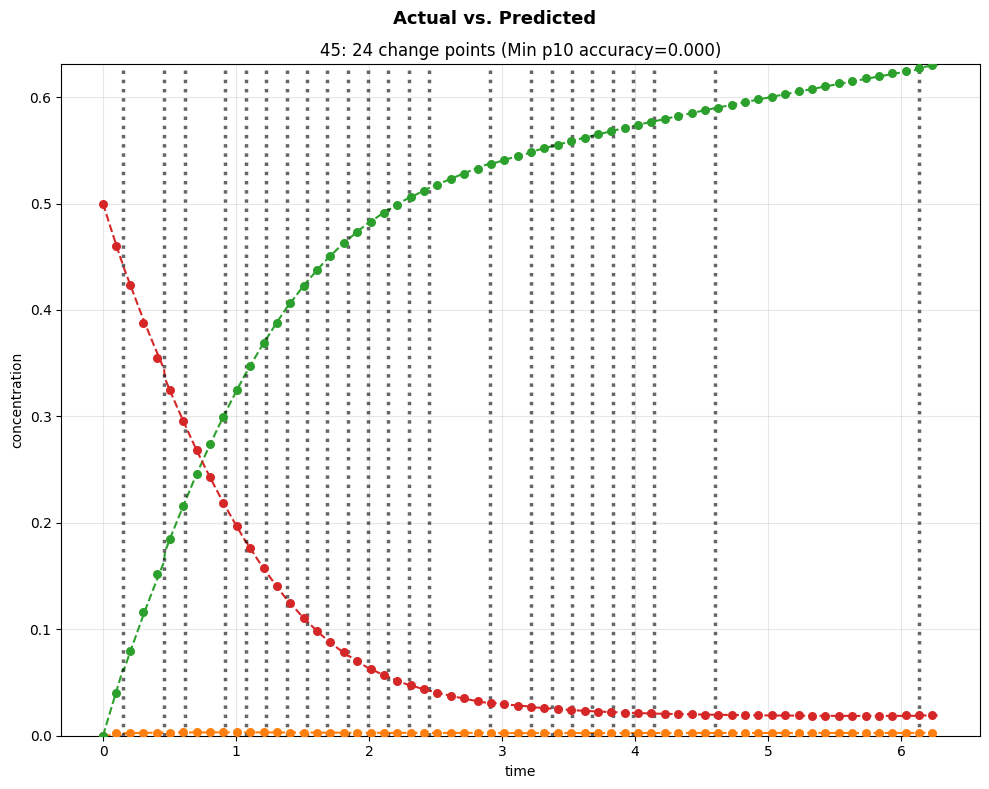

<Figure size 640x480 with 0 Axes>

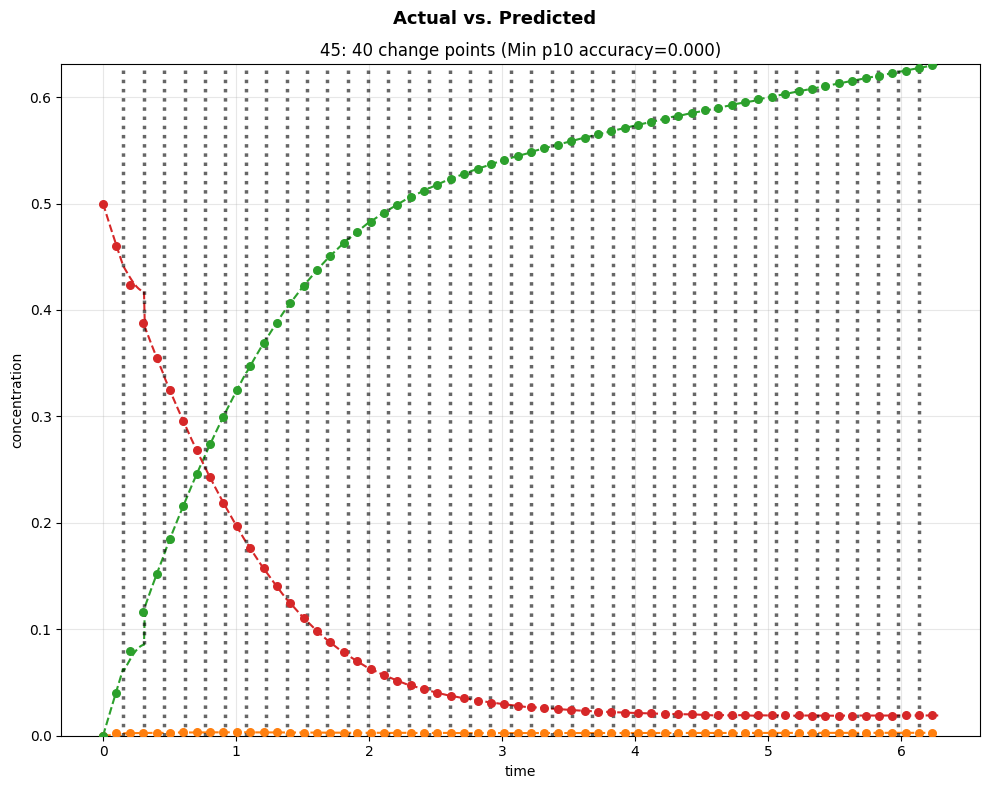

<Figure size 640x480 with 0 Axes>

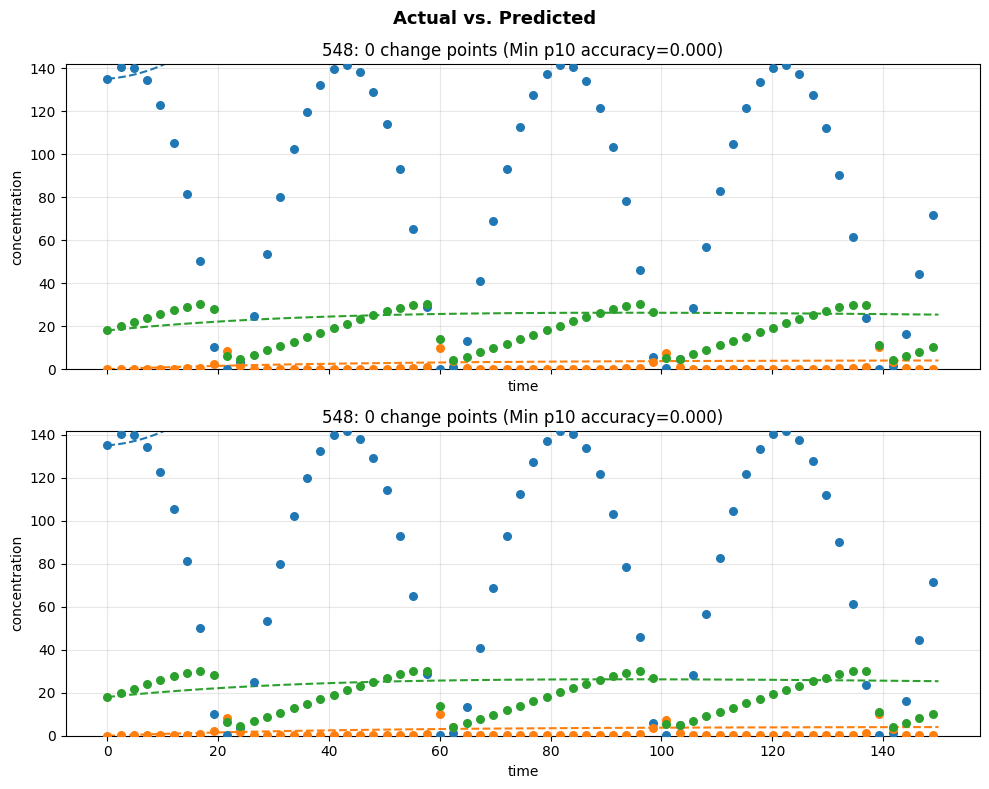

<Figure size 640x480 with 0 Axes>

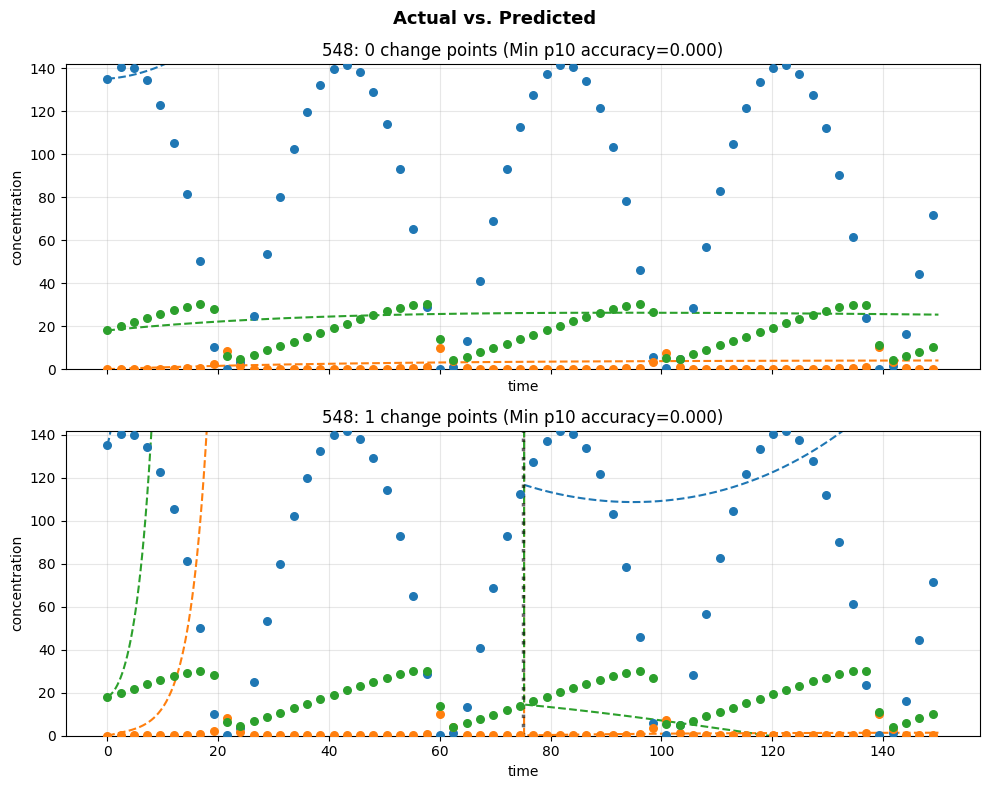

<Figure size 640x480 with 0 Axes>

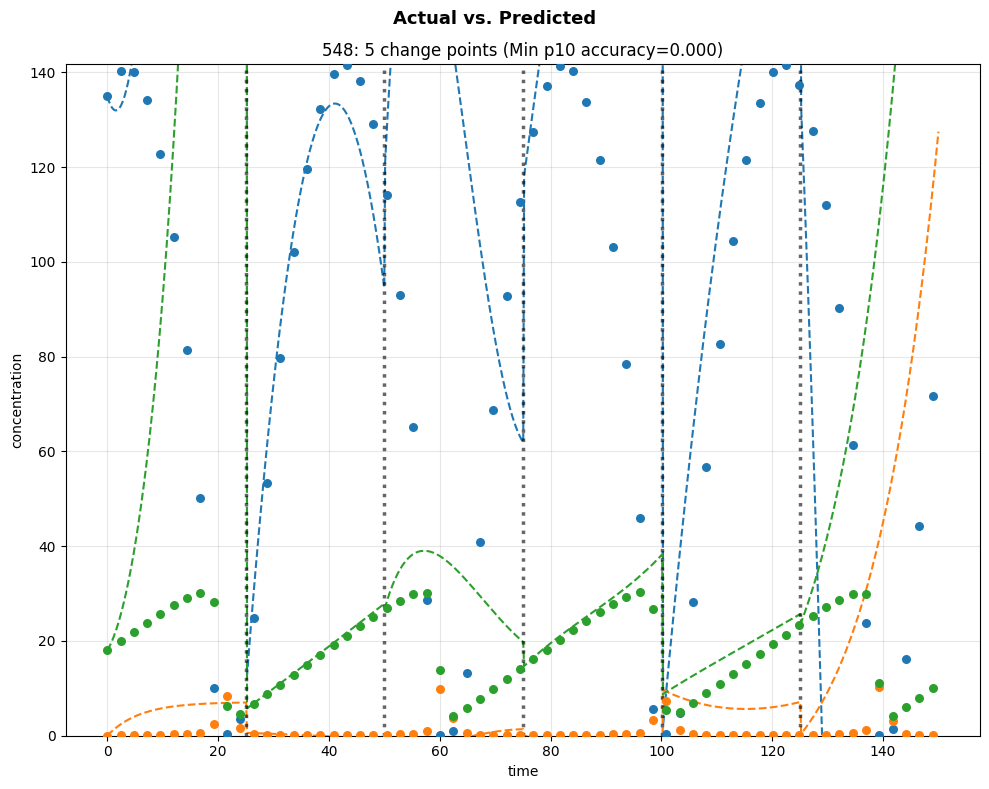

<Figure size 640x480 with 0 Axes>

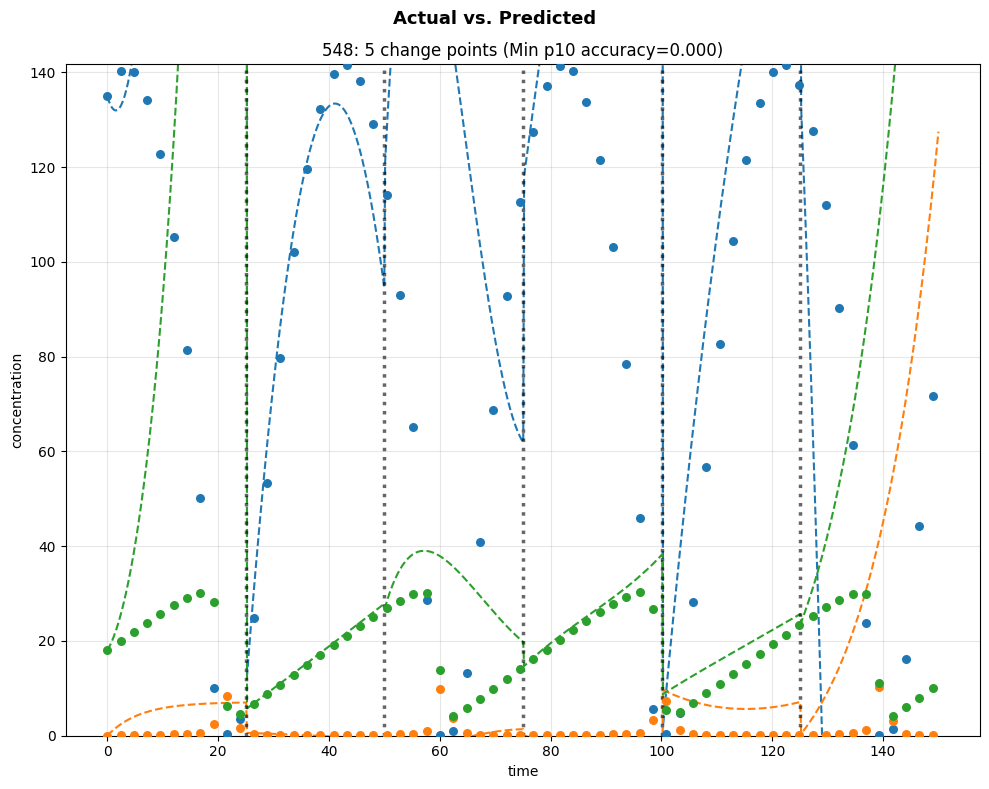

<Figure size 640x480 with 0 Axes>

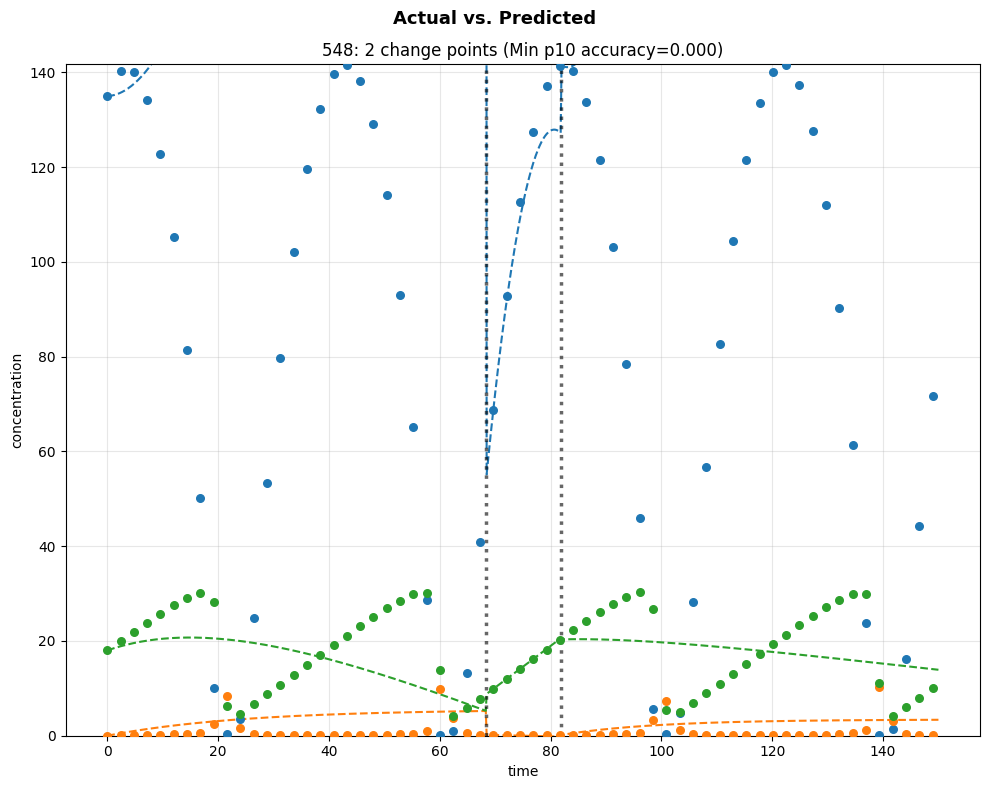

<Figure size 640x480 with 0 Axes>

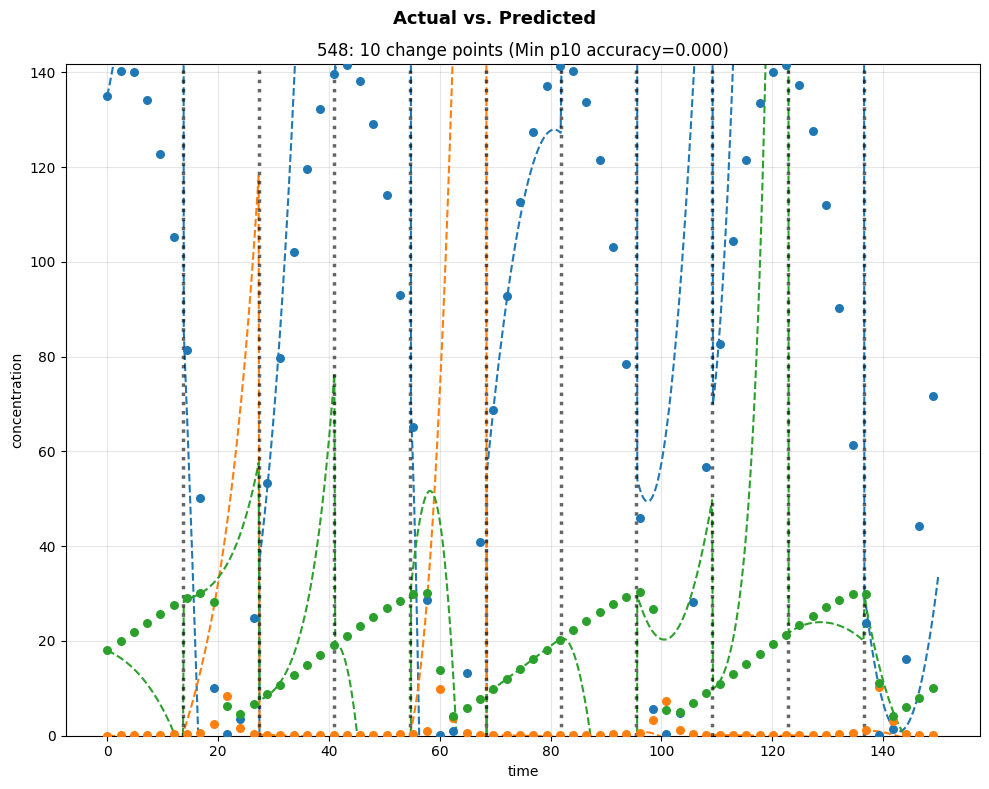

<Figure size 640x480 with 0 Axes>

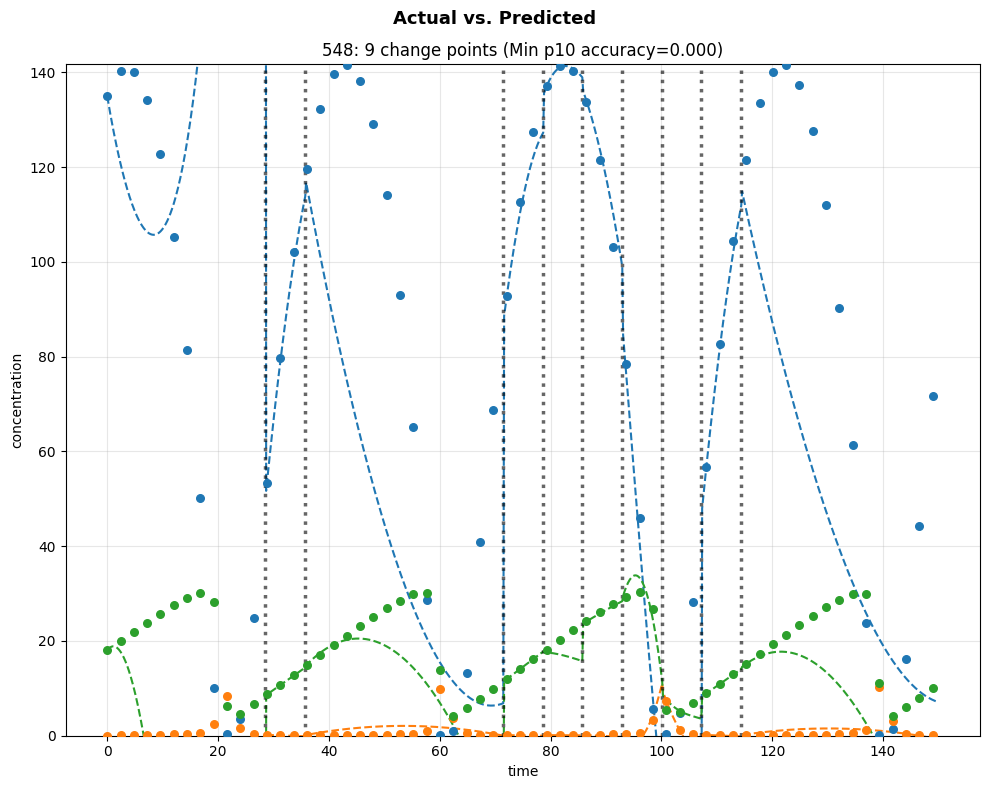

<Figure size 640x480 with 0 Axes>

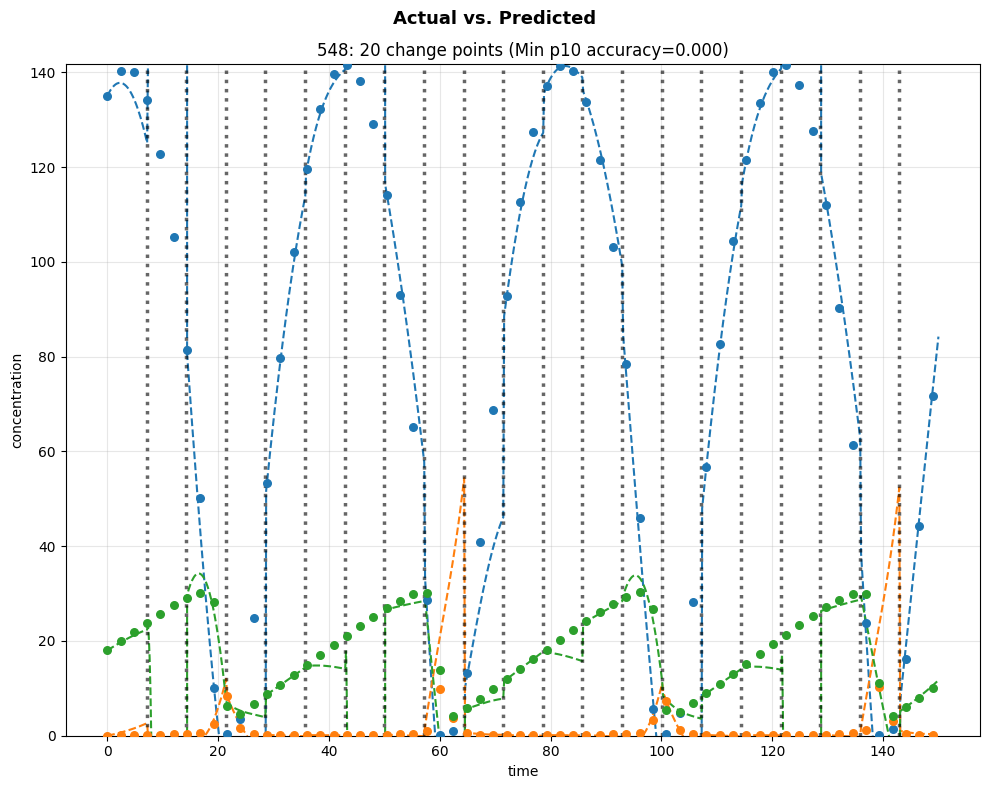

<Figure size 640x480 with 0 Axes>

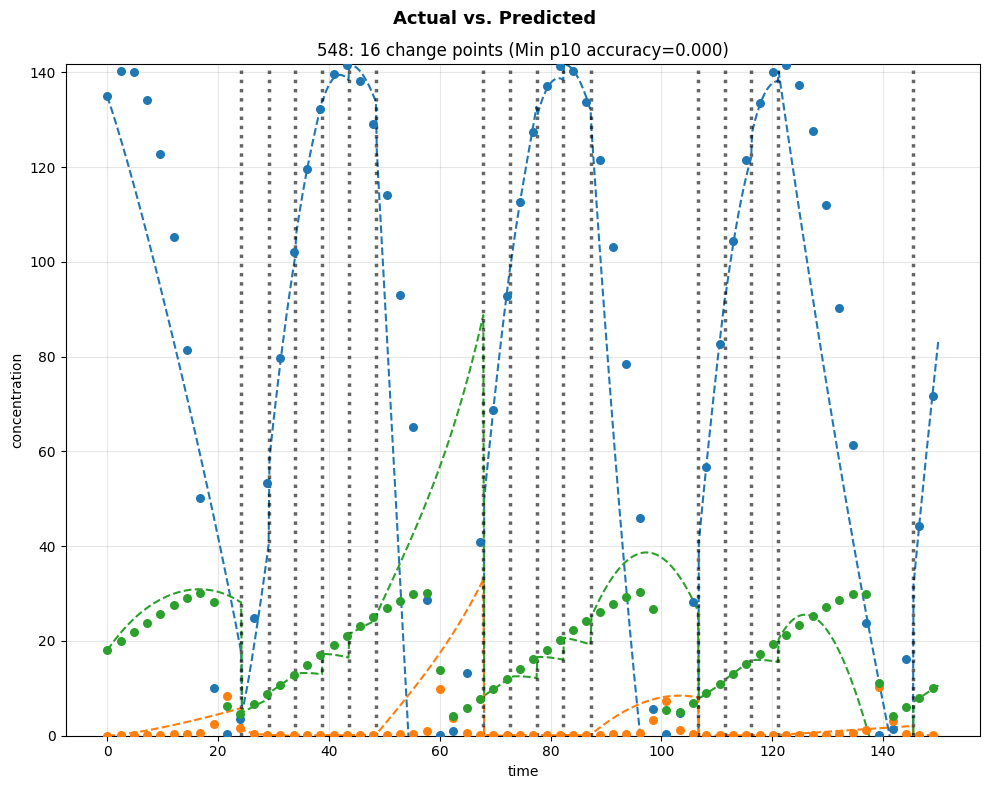

<Figure size 640x480 with 0 Axes>

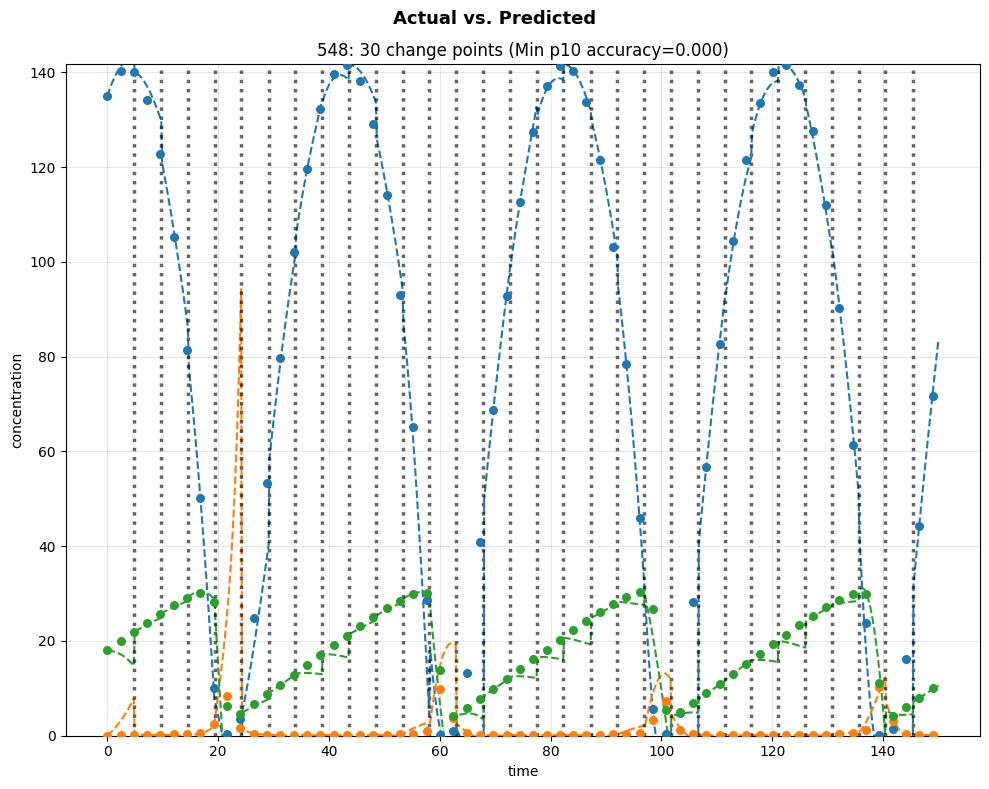

<Figure size 640x480 with 0 Axes>

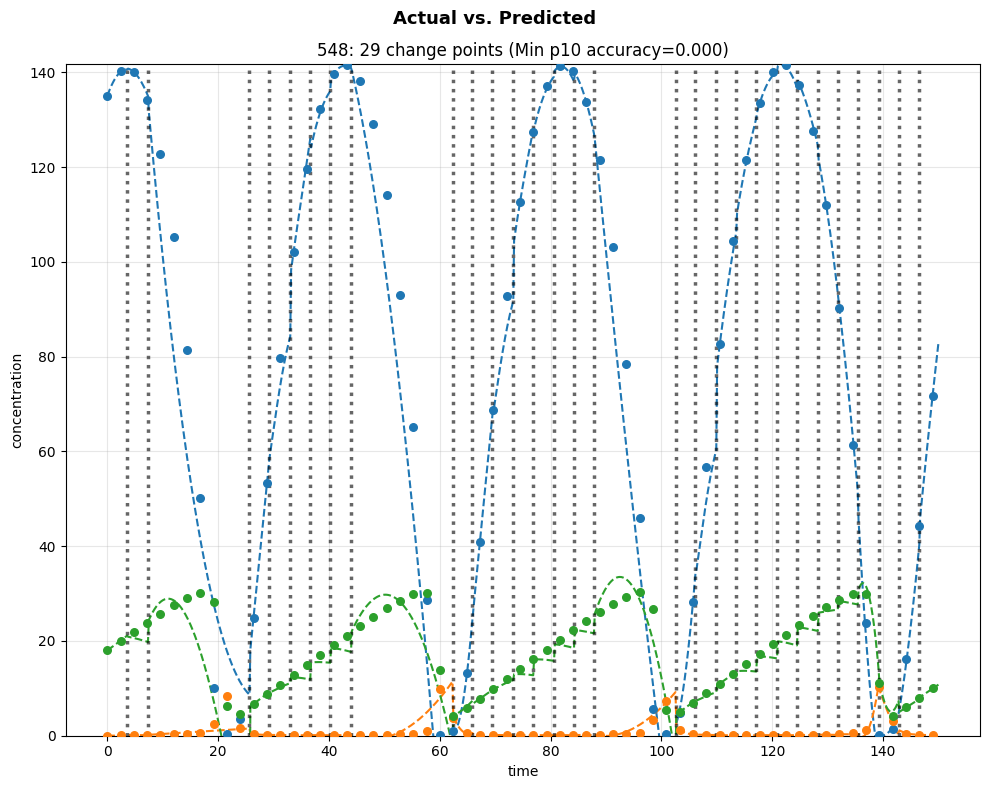

<Figure size 640x480 with 0 Axes>

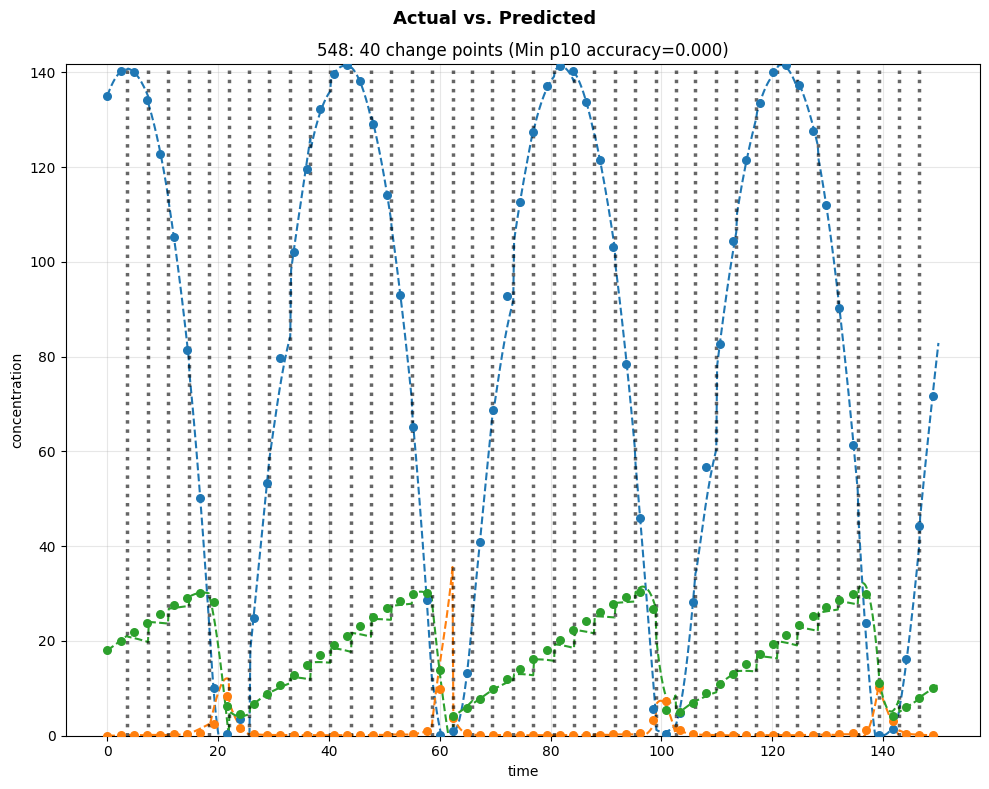

<Figure size 640x480 with 0 Axes>

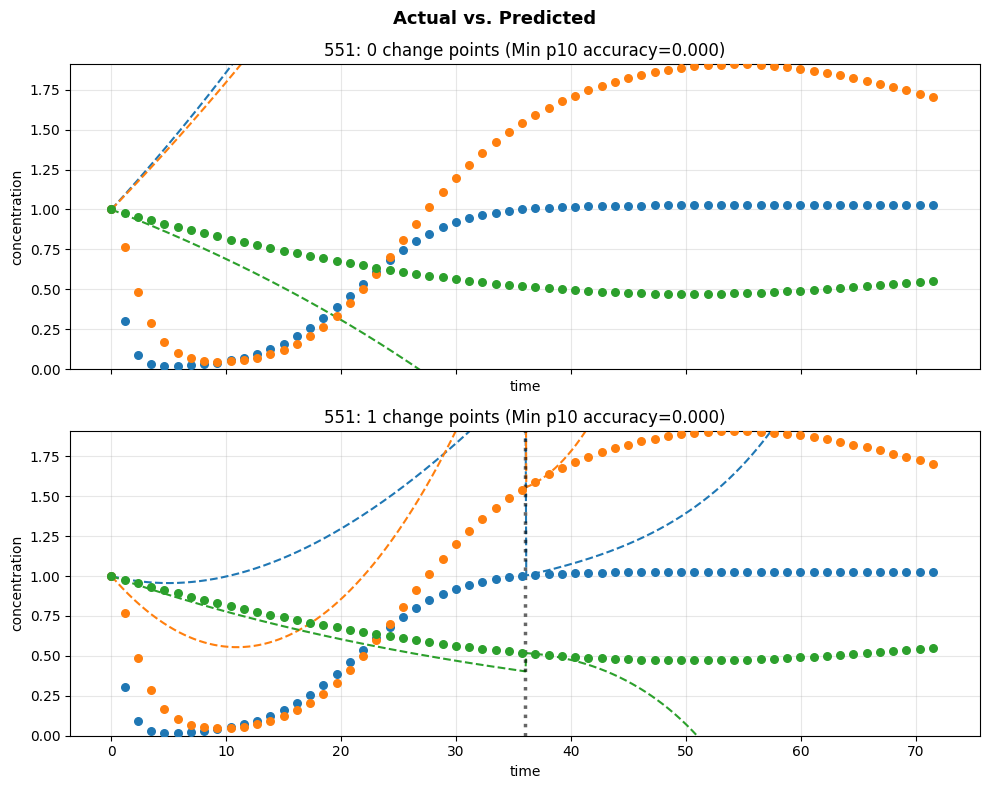

<Figure size 640x480 with 0 Axes>

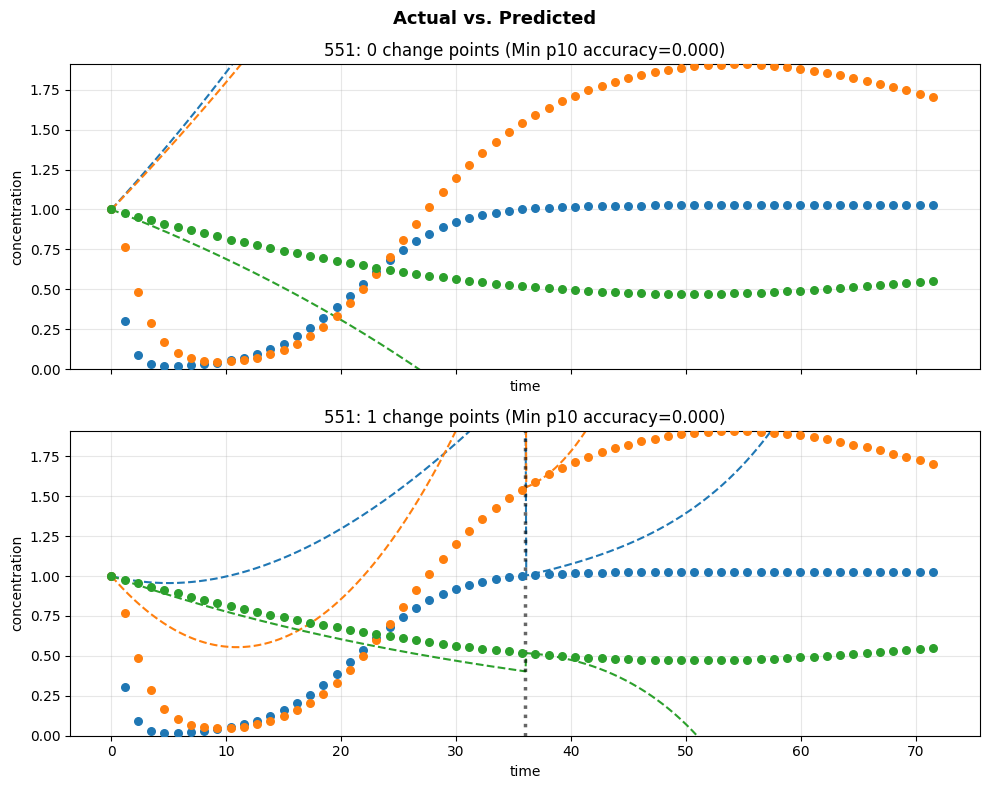

<Figure size 640x480 with 0 Axes>

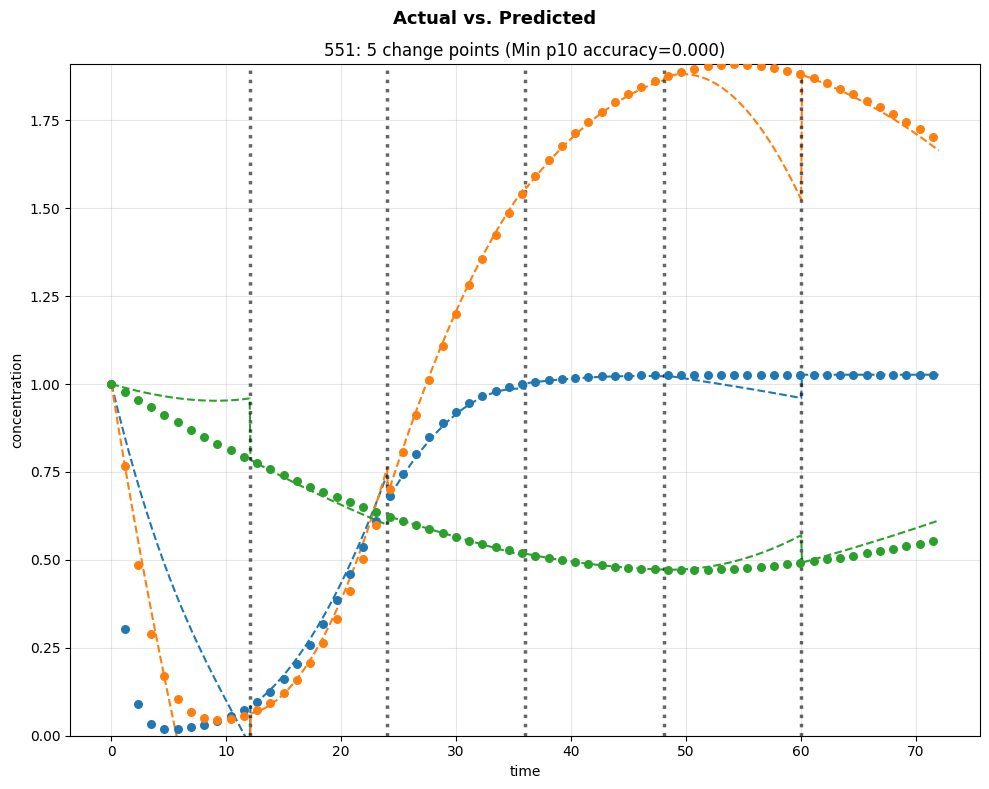

<Figure size 640x480 with 0 Axes>

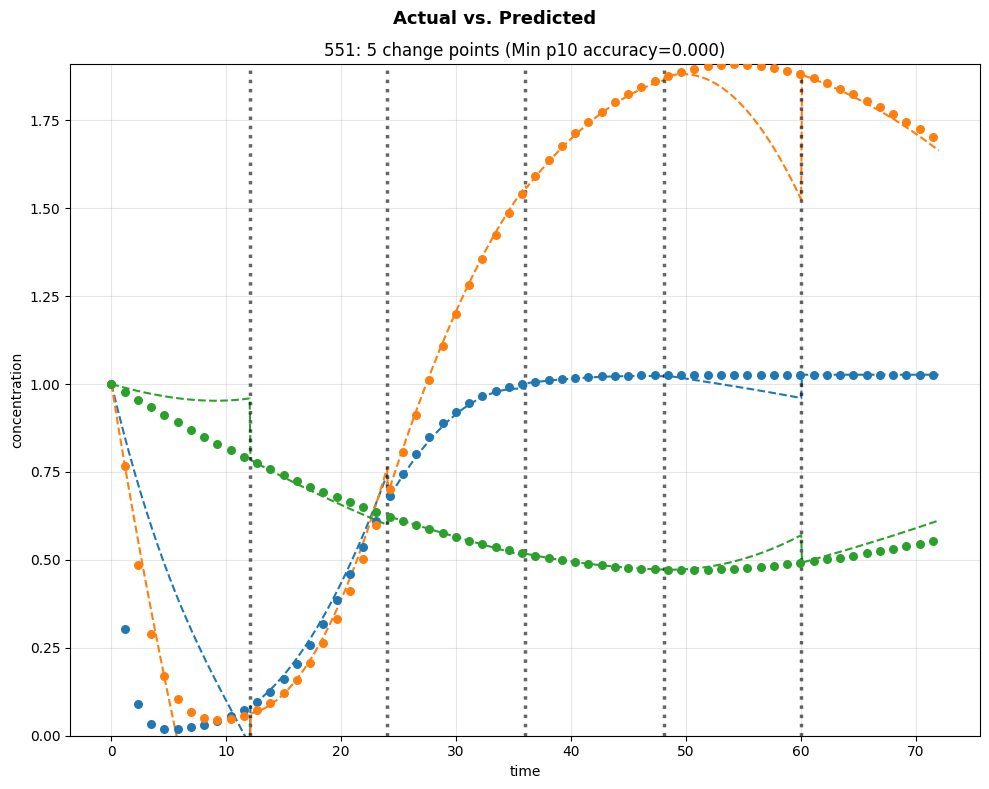

<Figure size 640x480 with 0 Axes>

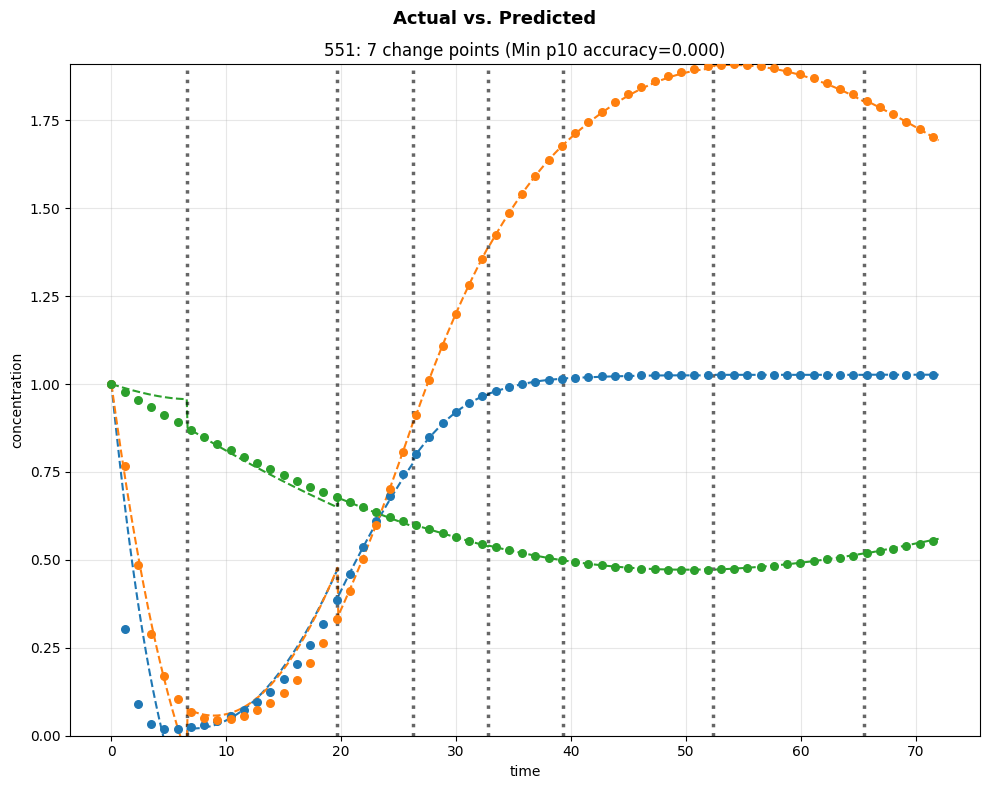

<Figure size 640x480 with 0 Axes>

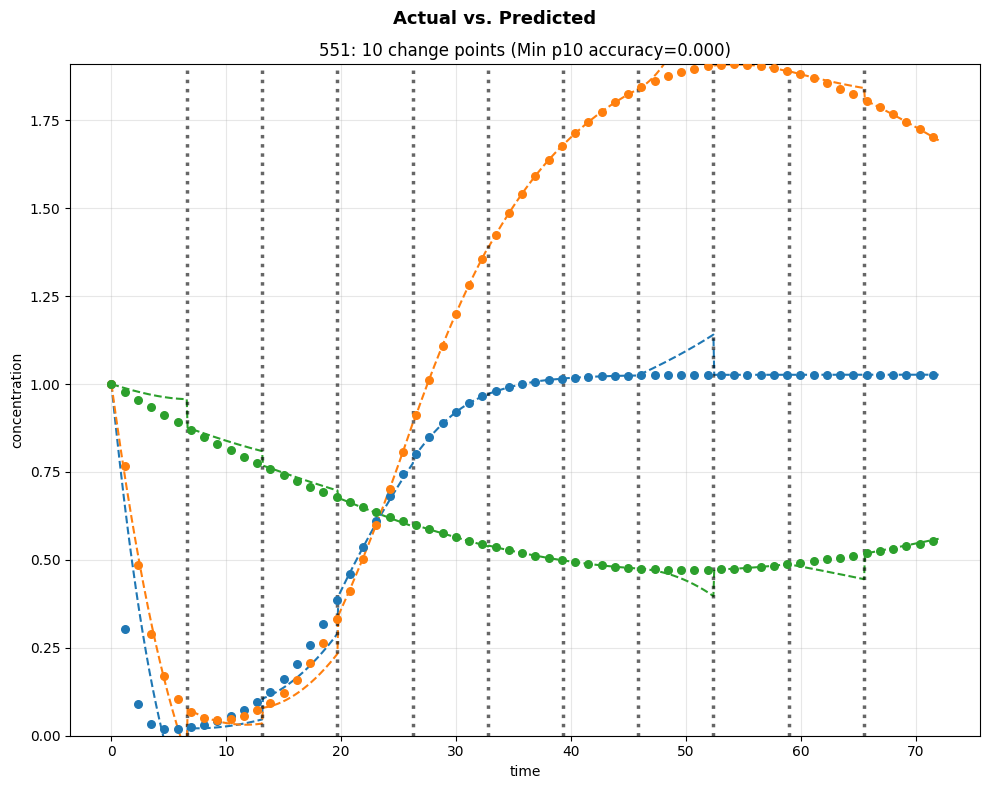

<Figure size 640x480 with 0 Axes>

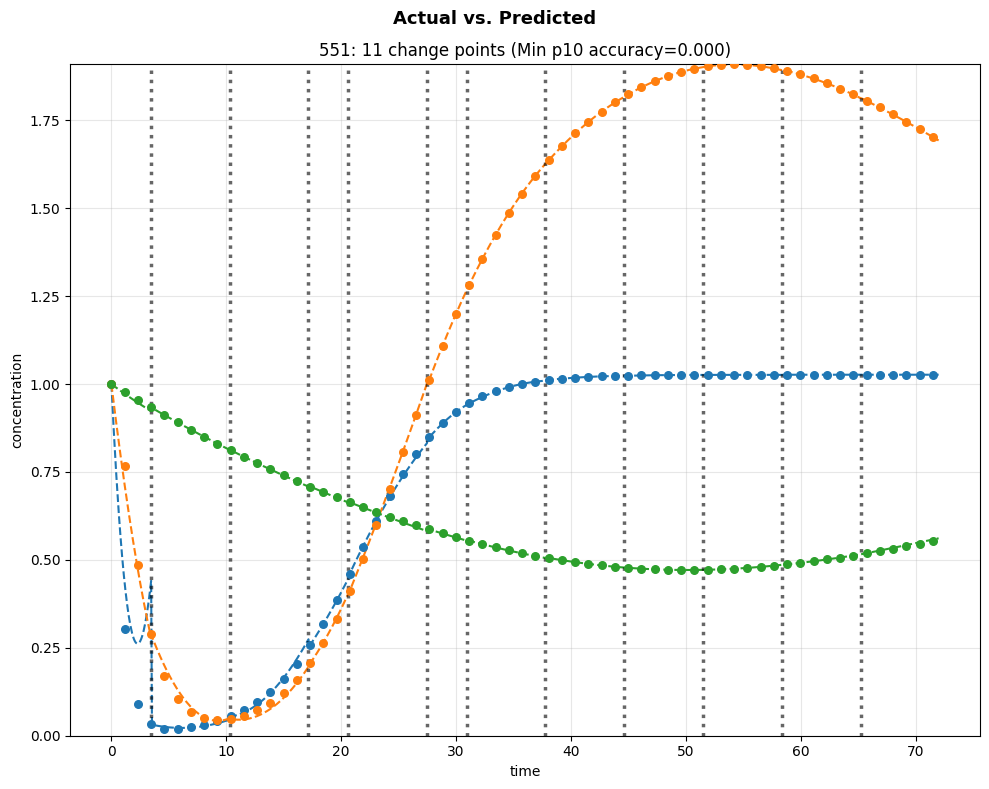

<Figure size 640x480 with 0 Axes>

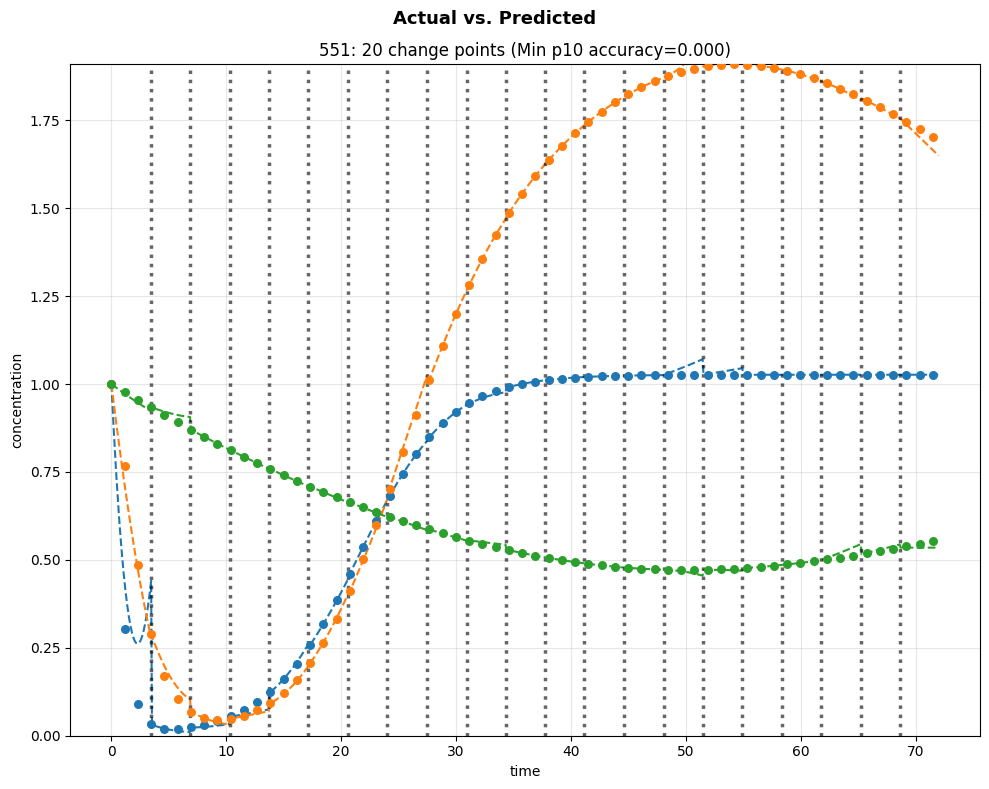

<Figure size 640x480 with 0 Axes>

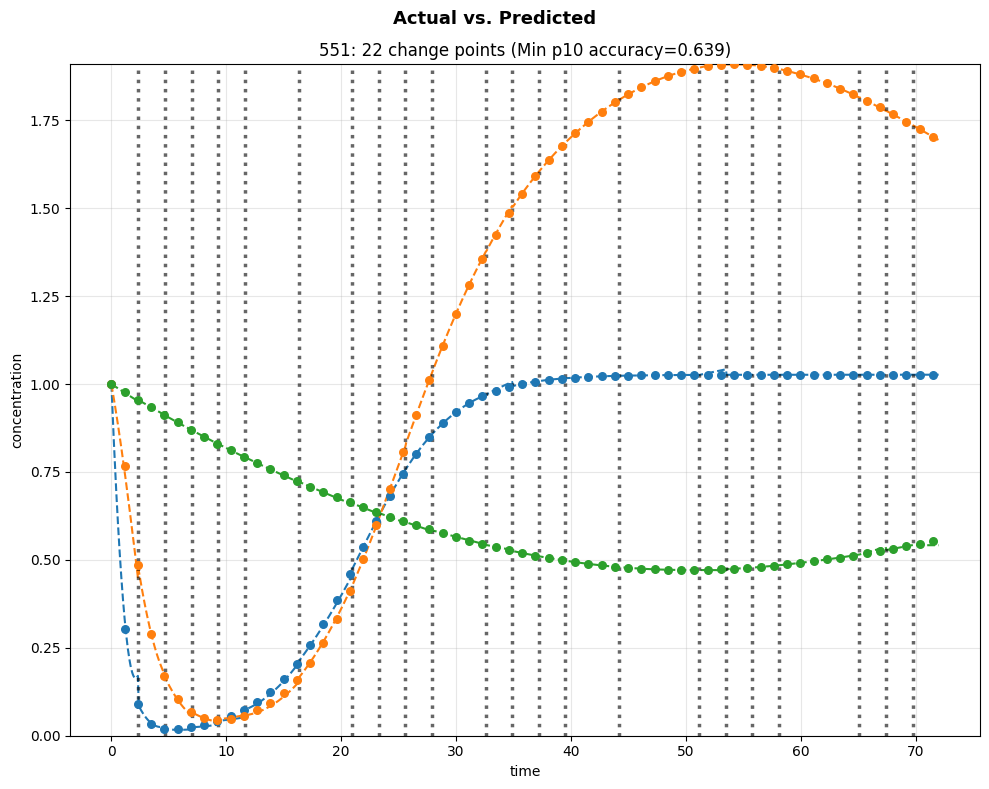

<Figure size 640x480 with 0 Axes>

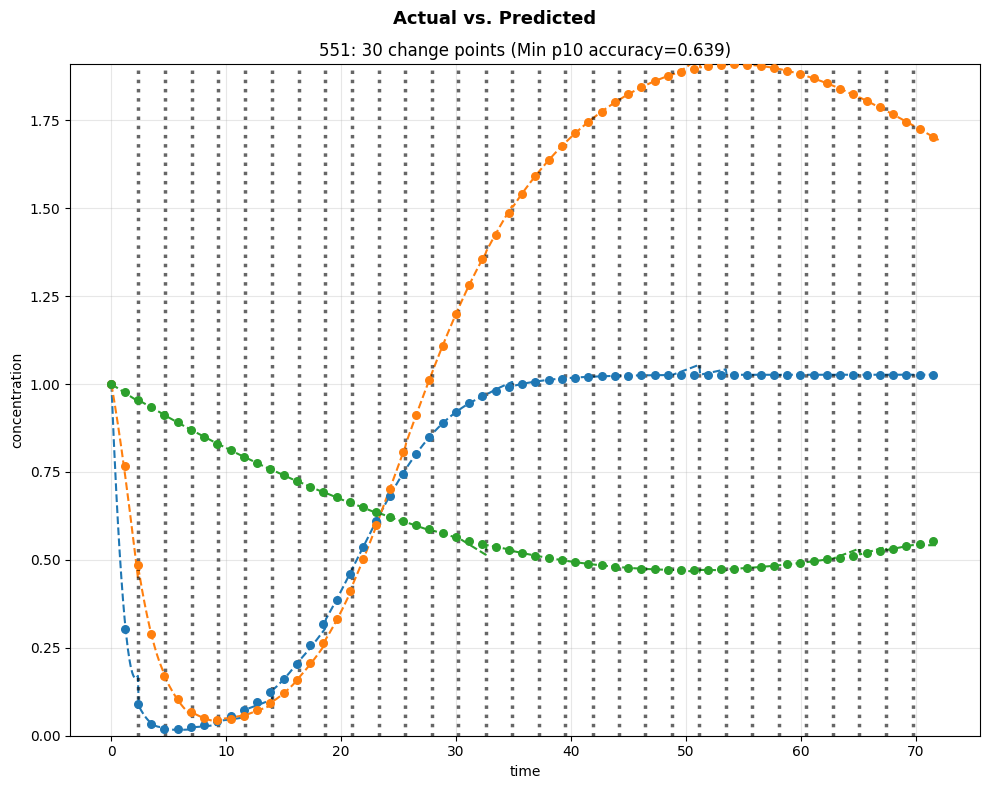

<Figure size 640x480 with 0 Axes>

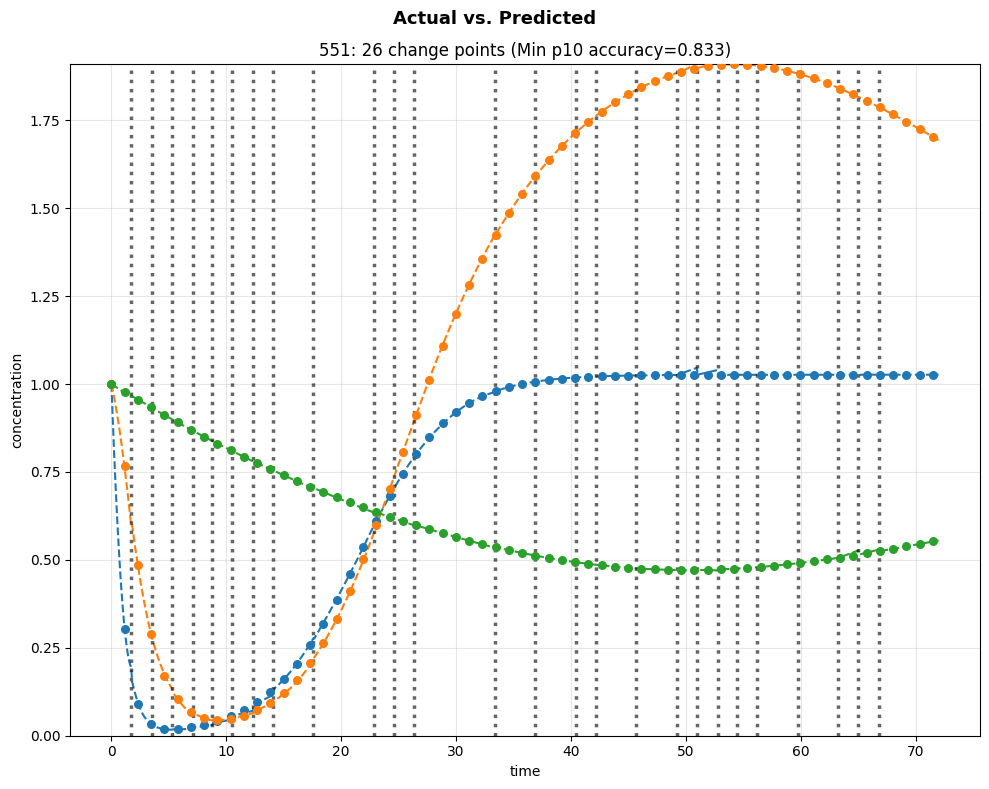

<Figure size 640x480 with 0 Axes>

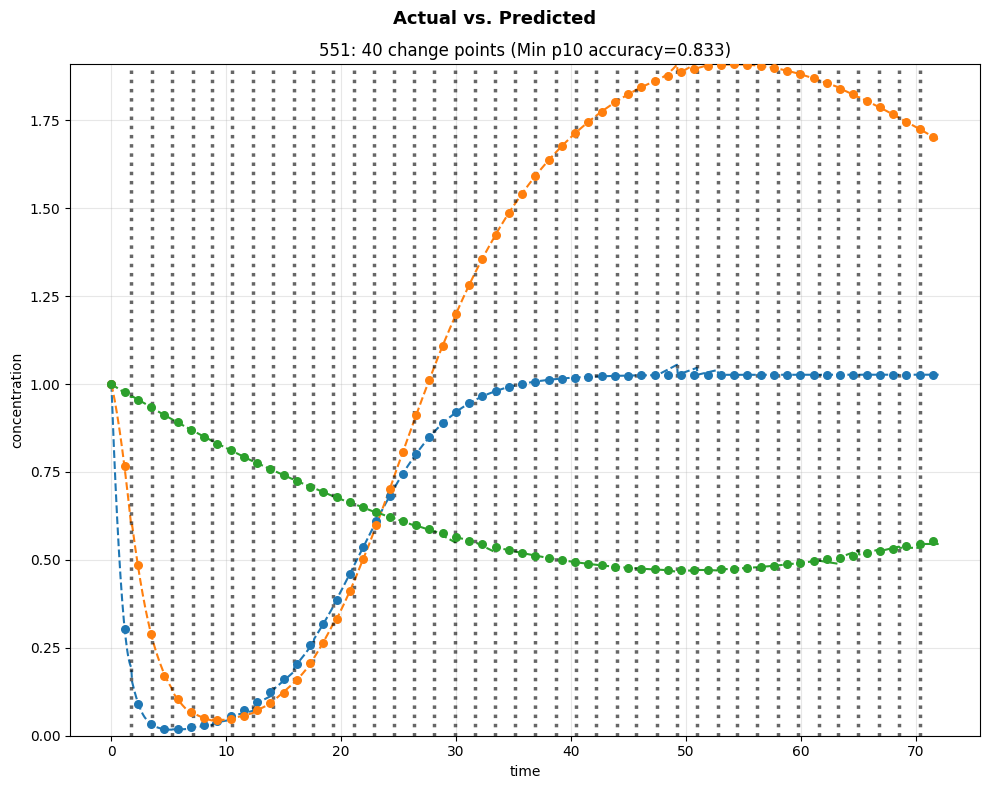

<Figure size 640x480 with 0 Axes>

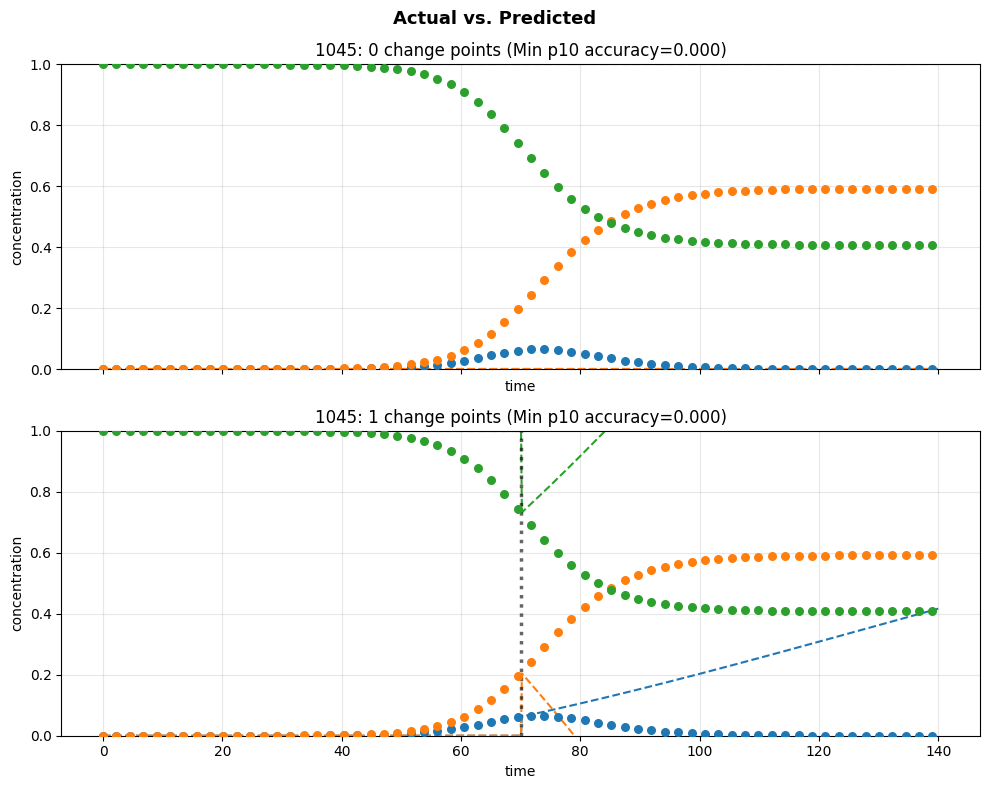

<Figure size 640x480 with 0 Axes>

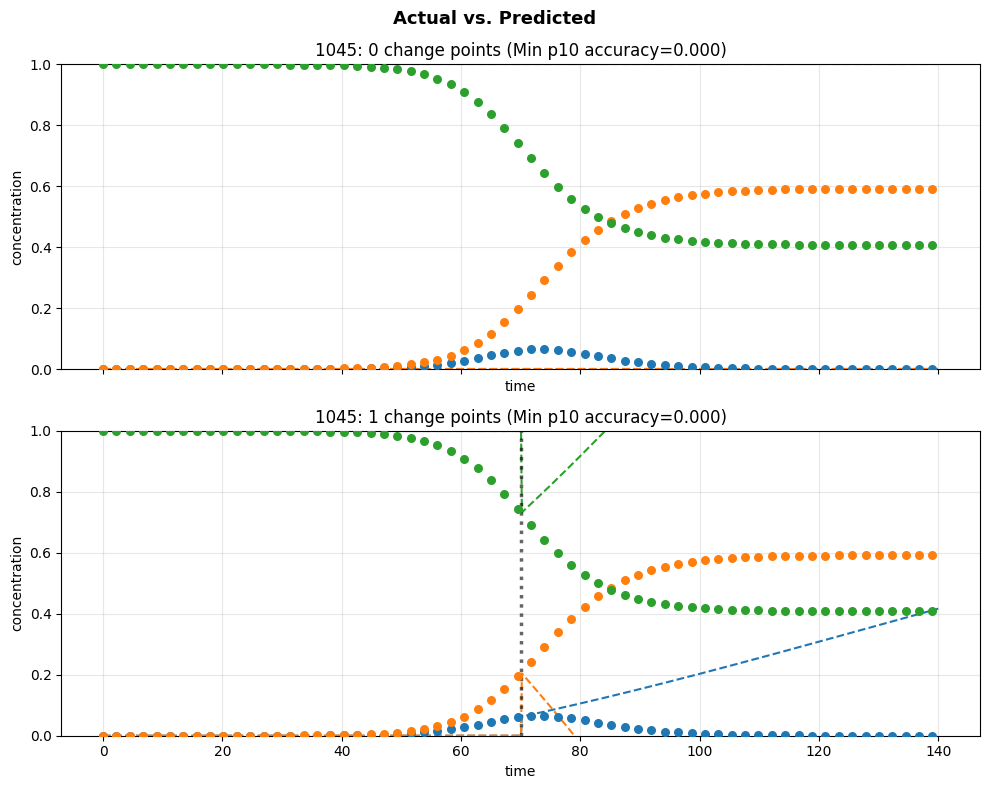

<Figure size 640x480 with 0 Axes>

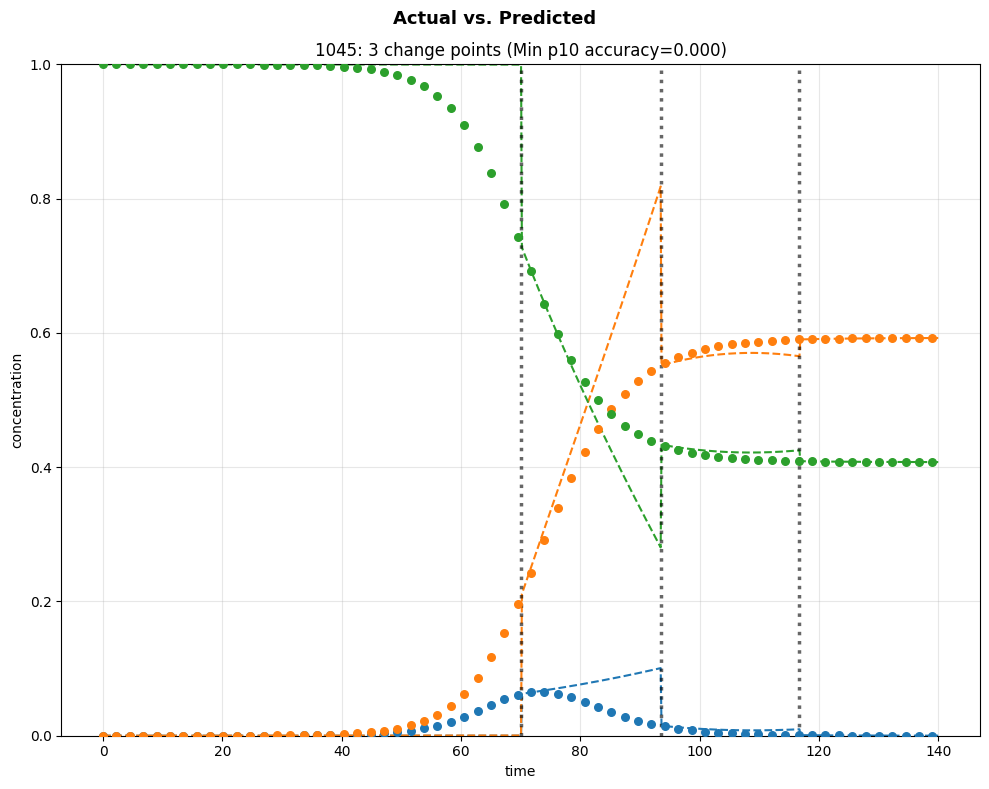

<Figure size 640x480 with 0 Axes>

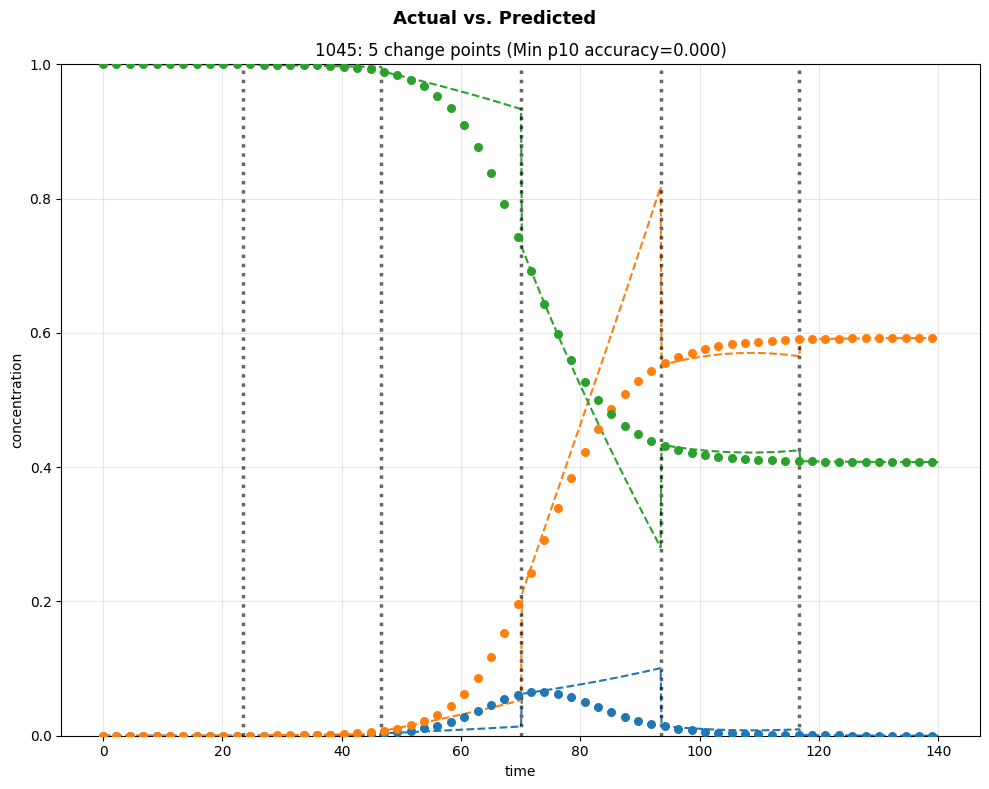

<Figure size 640x480 with 0 Axes>

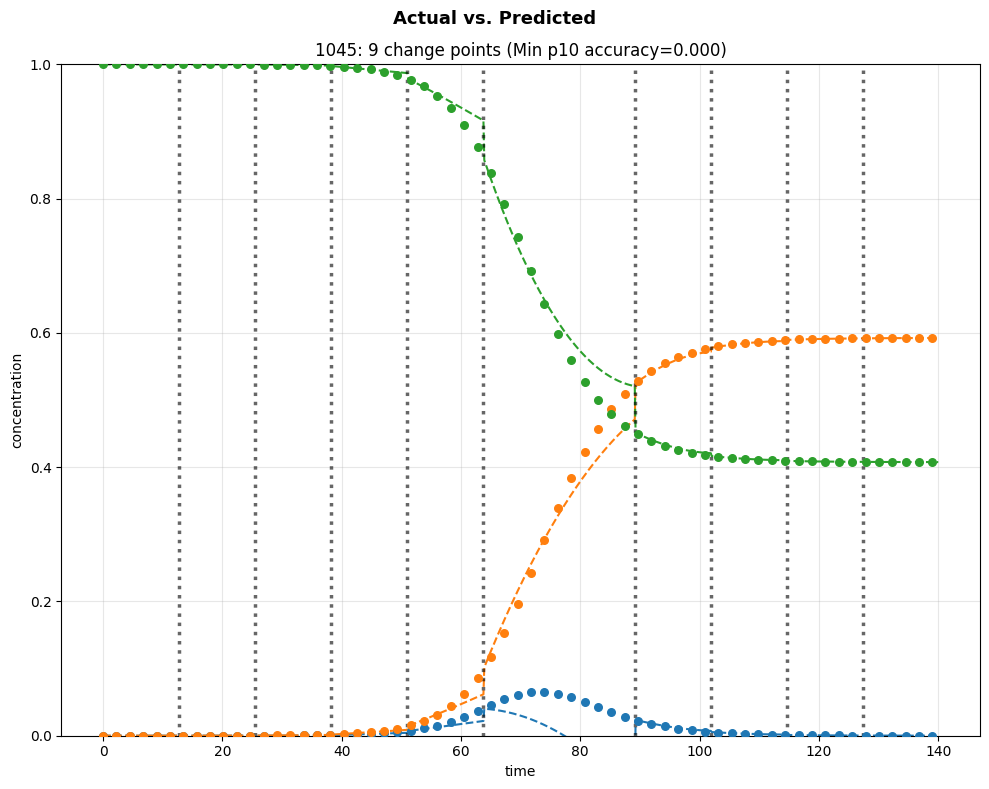

<Figure size 640x480 with 0 Axes>

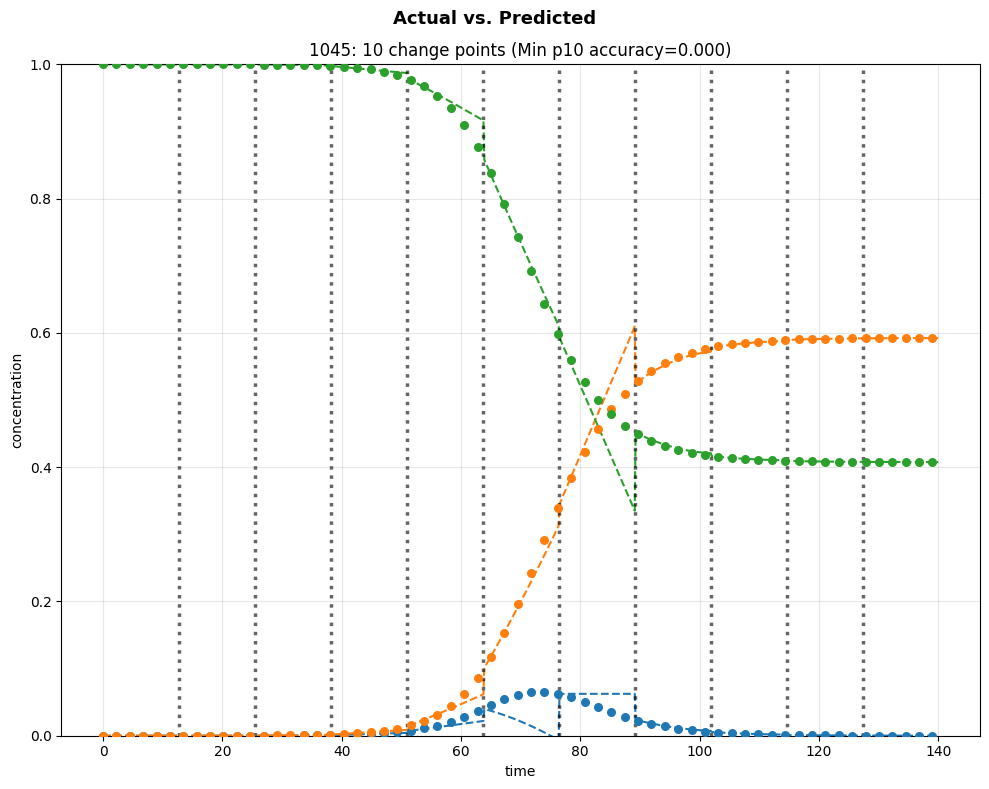

<Figure size 640x480 with 0 Axes>

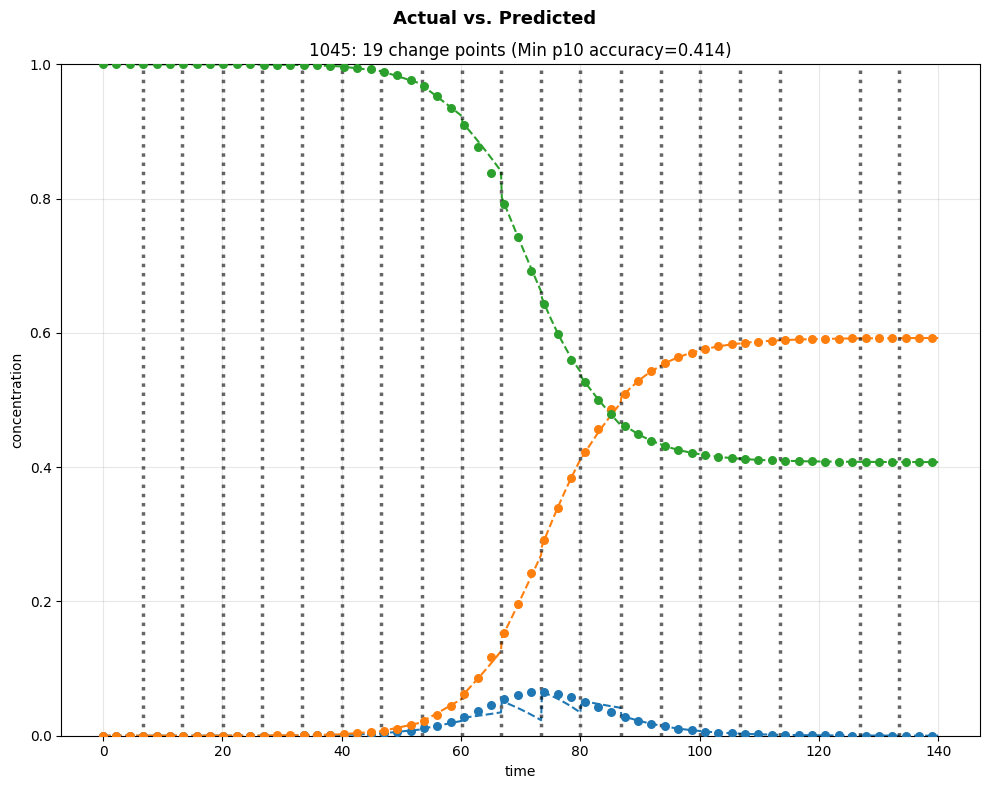

<Figure size 640x480 with 0 Axes>

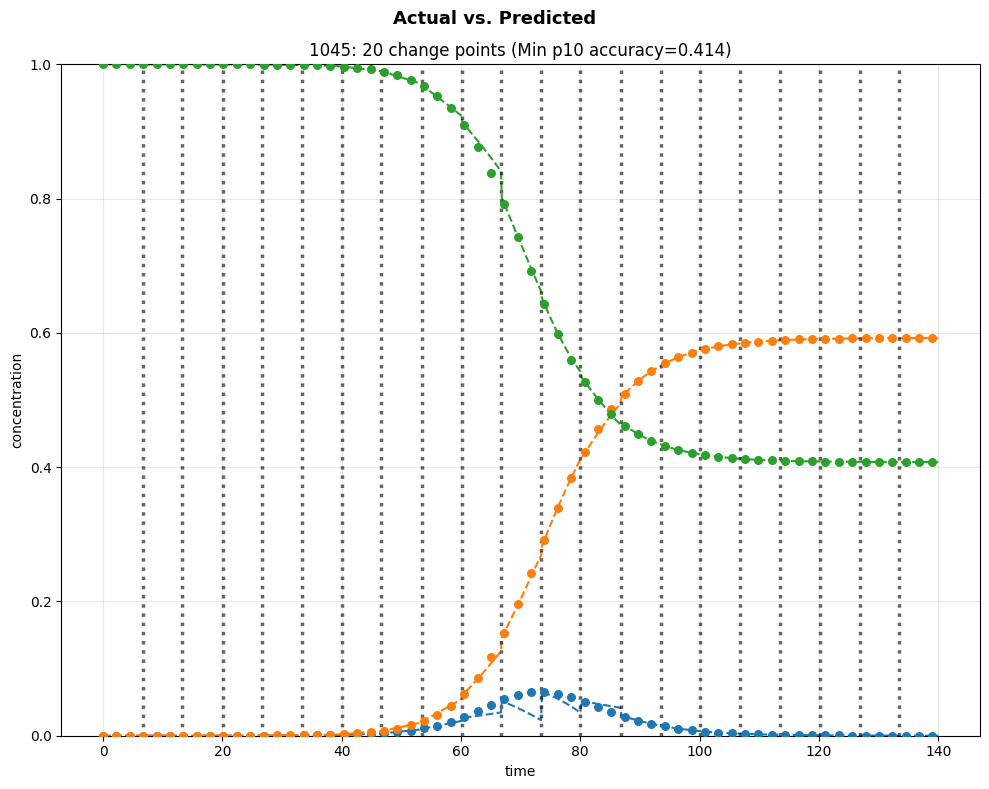

<Figure size 640x480 with 0 Axes>

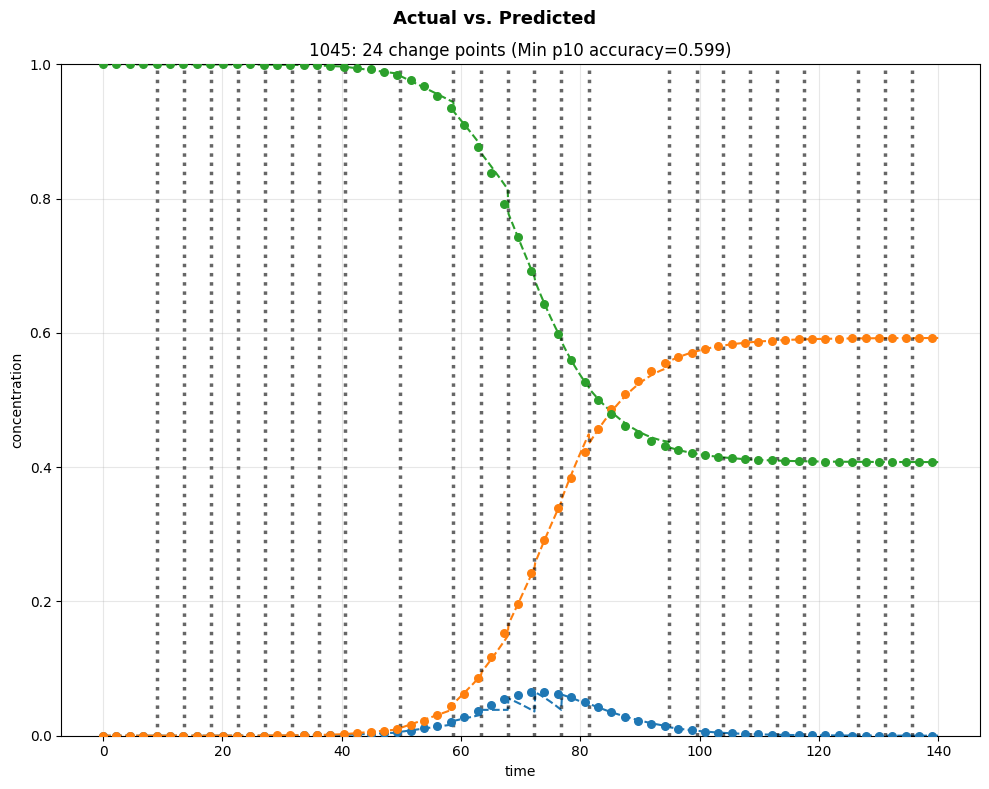

<Figure size 640x480 with 0 Axes>

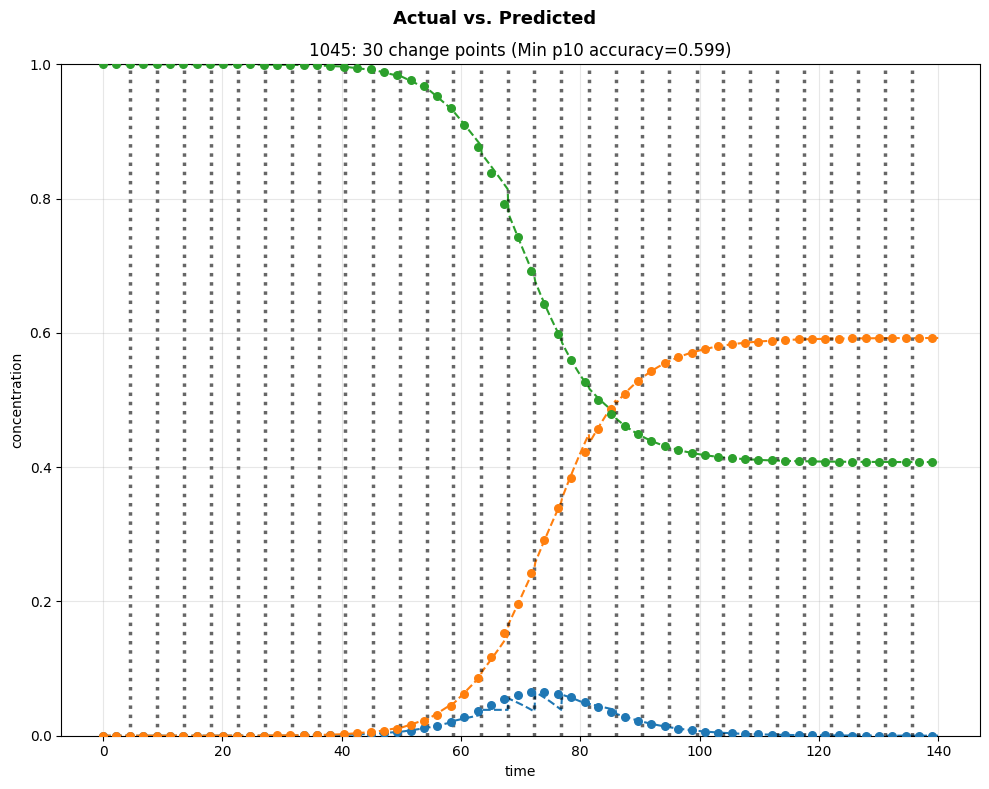

<Figure size 640x480 with 0 Axes>

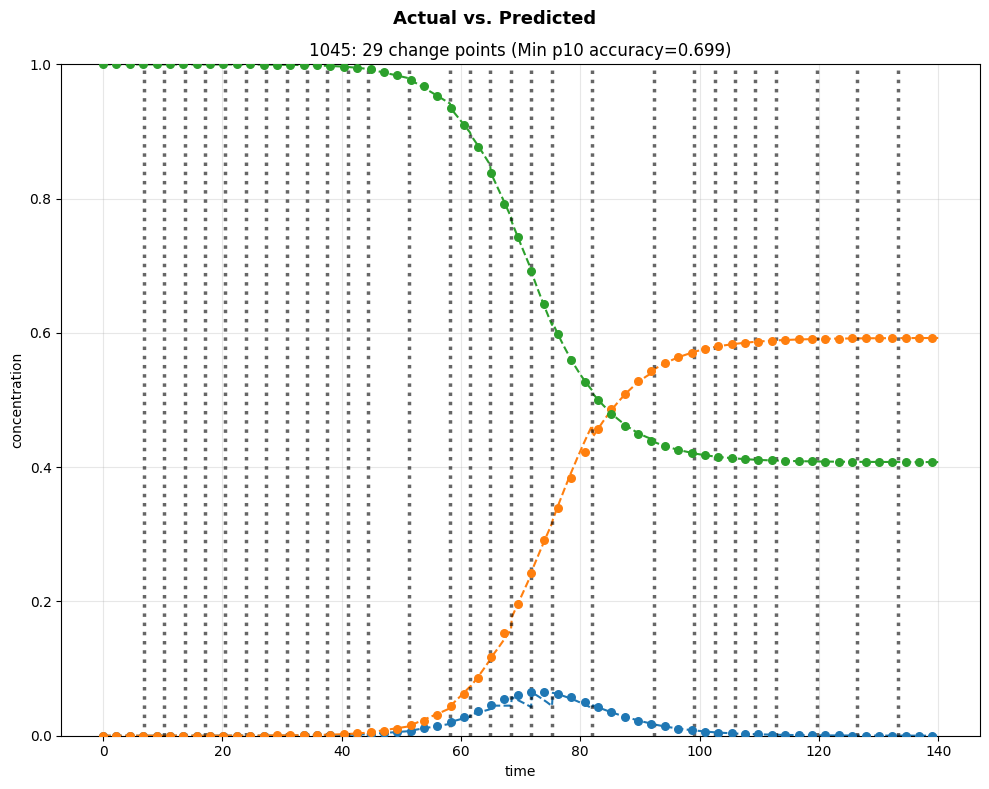

<Figure size 640x480 with 0 Axes>

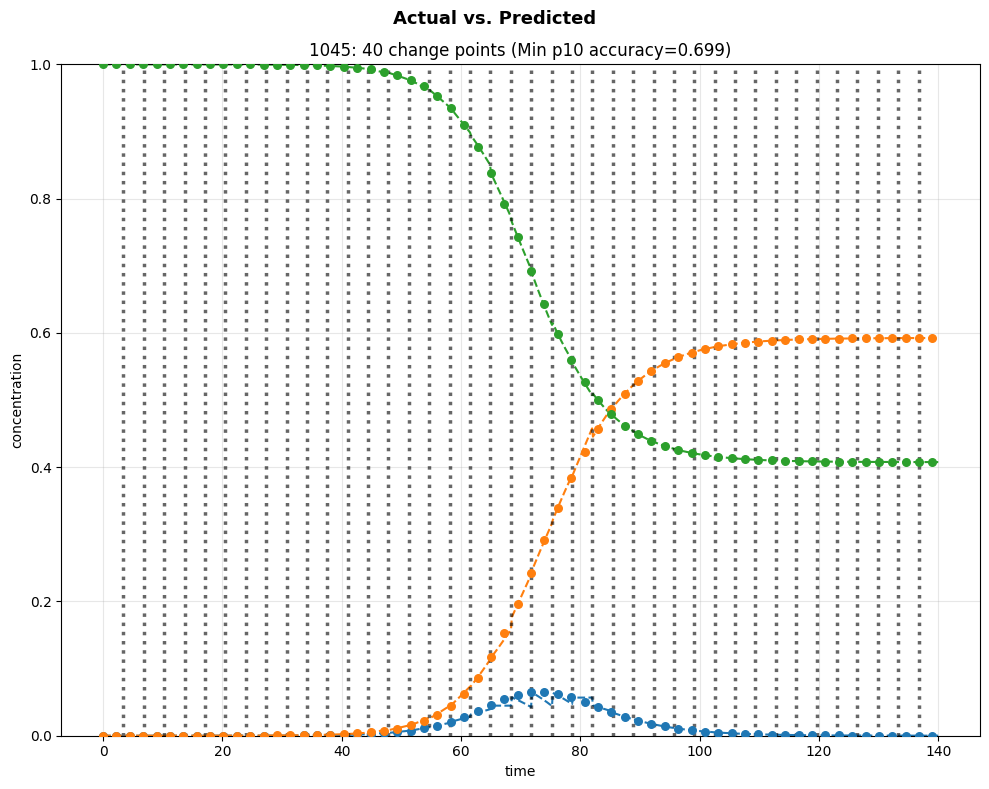

<Figure size 640x480 with 0 Axes>

In [3]:
for model_num in [45, 548, 551, 1045]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    specified_changepoints = list(range(10, 980, 30))
    try:
        for changepoint_idx, max_changepoint in enumerate([1, 5, 10, 20, 30, 40]):
            for is_changepoint_removal in [True, False]:
                psd = PiecewiseSystemDiscovery(df, 
                                               #changepoints=specified_changepoints,
                                               max_changepoint=max_changepoint,
                                               is_changepoint_removal=is_changepoint_removal,
                                                max_fractional_reduction=0.001, model_name=str(model_num))
                psd.fit()
                if changepoint_idx == 0:
                    result = psd.plotPiecewise(legend=False, num_true_point=60)
                else:
                    result = psd.plotPiecewise(legend=False, num_true_point=60, is_nochangepoint_plot=False)
                plt.figure()
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# Distribution of Number Species Across models

In [4]:
num_species_dct = {}
for item in TimecourseIterator():
    num_species_dct.update({item.model_name: len(item.timecourse.timecourse_df.columns)})
len(num_species_dct)

430

In [5]:
[m for m, s in num_species_dct.items() if s > 100]

['BIOMD0000000474', 'BIOMD0000000667']

Text(0.5, 1.0, 'Number Species per Model')

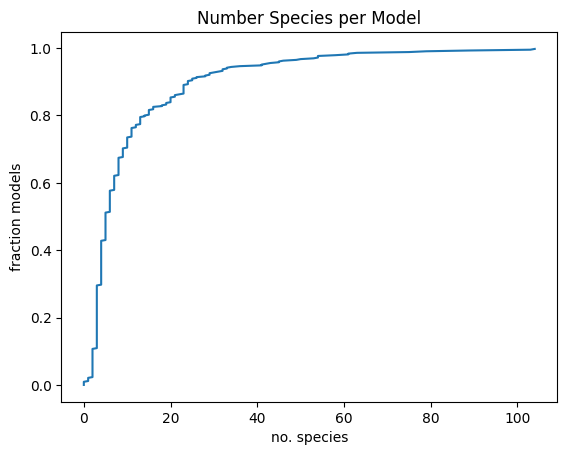

In [6]:
values = np.sort(list(num_species_dct.values()))
yv = np.array(range(len(values)))/len(values)
plt.plot(values, yv)
plt.xlabel("no. species")
plt.ylabel("fraction models")
plt.title("Number Species per Model")

Text(0.5, 1.0, 'CDF of Species by Model Size')

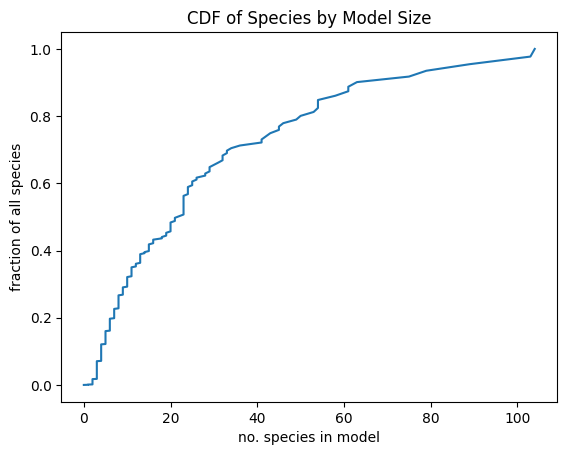

In [7]:
frac_species = np.cumsum(values)/np.sum(values)
_, ax = plt.subplots(1)
ax.plot(values, frac_species)
ax.set_xlabel("no. species in model")
ax.set_ylabel("fraction of all species")
ax.set_title("CDF of Species by Model Size")

# CDFs

## All Models

In [8]:
threshold = 0.001
#path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
DF = pd.read_csv(path)
DF

/var/folders/02/lb248q1j50dch2pthzkvxmpr0000gn/T/ipykernel_58877/563442930.py:4: DtypeWarning: Columns (0: is_changepoint_removal) have mixed types. Specify dtype option on import or set low_memory=False.
  DF = pd.read_csv(path)


,system_id,aggregation_type,mean,min,max,count,invalid_count,p05,p10,p20,...,a90,a95,changepoints,max_changepoint,min_segment_length,max_fractional_reduction,coefficient_threshold,num_changepoint,is_changepoint_removal,num_species
0,BIOMD0000000005,model,0.000000,0.000000,0.000000,6,0,0.000000,0.000000,0.000000,...,0.000000,0.000000,[500],1.0,50.0,0.01,0.001,1.0,False,6.0
1,BIOMD0000000005,C2,0.027308,0.000000,0.991822,999,1,0.000000,0.000000,0.000000,...,0.010010,0.007007,[500],1.0,50.0,0.01,0.001,1.0,False,6.0
2,BIOMD0000000005,CP,0.033320,0.000000,1.000000,1000,0,0.000000,0.000000,0.000000,...,0.009000,0.006000,[500],1.0,50.0,0.01,0.001,1.0,False,6.0
3,BIOMD0000000005,M,0.001033,0.000000,0.841136,999,1,0.000000,0.000000,0.000000,...,0.000000,0.000000,[500],1.0,50.0,0.01,0.001,1.0,False,6.0
4,BIOMD0000000005,pM,0.007188,0.000000,1.000000,1000,0,0.000000,0.000000,0.000000,...,0.002000,0.001000,[500],1.0,50.0,0.01,0.001,1.0,False,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86635,BIOMD0000001015,N,0.987693,0.584694,1.000000,1000,0,0.944833,0.969497,0.989189,...,0.976000,0.944000,"[16, 33, 49, 66, 82, 98, 115, 131, 148, 164, 1...",60.0,50.0,0.01,0.001,60.0,False,6.0
86636,BIOMD0000001015,R,0.985558,0.570922,0.999999,999,1,0.936632,0.971701,0.987814,...,0.960961,0.939940,"[16, 33, 49, 66, 82, 98, 115, 131, 148, 164, 1...",60.0,50.0,0.01,0.001,60.0,False,6.0
86637,BIOMD0000001015,model,0.967473,0.915784,0.994107,6,0,0.926111,0.936437,0.957090,...,1.000000,0.833333,"[14, 28, 42, 56, 70, 85, 99, 113, 127, 141, 15...",70.0,50.0,0.01,0.001,70.0,False,6.0
86638,BIOMD0000001015,H,0.993279,0.676897,1.000000,999,1,0.977241,0.990948,0.997070,...,0.980981,0.966967,"[14, 28, 42, 56, 70, 85, 99, 113, 127, 141, 15...",70.0,50.0,0.01,0.001,70.0,False,6.0


In [9]:
def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10,
        is_oscillation: bool = True) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    # Handle oscillations
    if not is_oscillation:
        pass
        
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

43       0.327327
44       0.434000
45       0.045045
46       0.201000
47       0.410410
           ...   
86597    0.539540
86598    0.468000
86599    0.431000
86600    0.609000
86601    0.484484
Name: a80, Length: 3104, dtype: float64

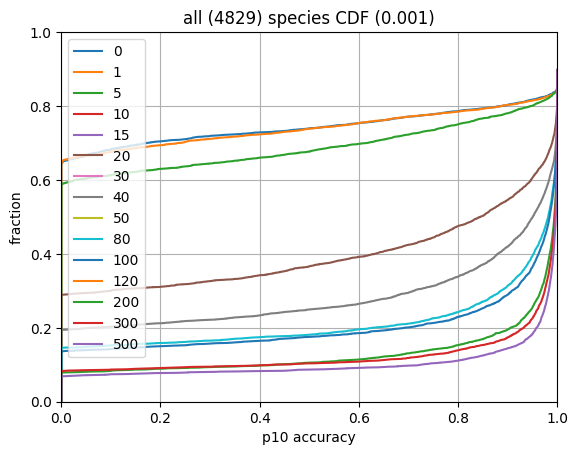

In [24]:
def plotCDF(coefficient_threshold: float = 0.001, max_changepoints=[0, 1, 5, 10, 15, 20, 30, 40, 50, 80, 100, 120, 200, 300, 500], is_species: bool = True, col="p10",
        is_non_oscillating: Optional[bool] = None):
    # Construct the dataframe to process
    #path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{coefficient_threshold}.csv")
    path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
    df = pd.read_csv(path)
    df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
    if is_non_oscillating is not None:
        df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
        #
        sel = df["key"].isin(NONOSCILLATION_DF["key"].unique())
        if is_non_oscillating:
            df = df[sel]
        else:
            df = df[~sel]
    #
    dct = {c: getColumn(df, col=col, max_changepoint = c, is_species=is_species) for c in max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in max_changepoints])
    ax.set_xlabel(col + " accuracy")
    qualifier1 = "species" if is_species else "models"
    model_sel = (df[cn.COL_AGGREGATION_TYPE] == "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
    species_sel = (df[cn.COL_AGGREGATION_TYPE] != "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
    species_length = np.sum(species_sel)
    model_length = np.sum(model_sel)
    if is_species:
        length = species_length
    else:
        length = model_length
    if is_non_oscillating is None:
        qualifier2 = "all"
    else:
        qualifier2 = "non-oscillating" if is_non_oscillating else "oscillating"
    ax.set_title(f"{qualifier2} ({length}) {qualifier1} CDF ({coefficient_threshold})")

plotCDF(coefficient_threshold=0.001, is_species=True)

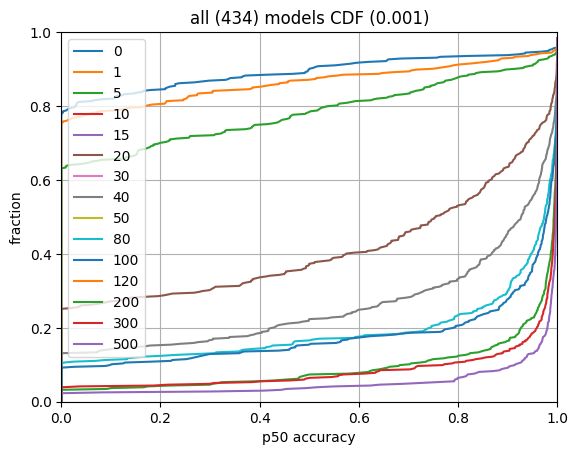

In [26]:
plotCDF(coefficient_threshold=0.001, is_species=False, col="p50")

**Observations**
1. Increasing the number of changepoints increases accuracy up to about 20 changepoints.
2. There is decreasing benefit of increasing the number of changepoints. For example, going from 0 to 1 changepoint, increases the fraction of p10 = 0.8  by 5%, but there is almost no increase the this fraction by increasing from 10 changepoints to 20 changepoints.
3. About 40% of the species trajectories have a p10 accuracy of 0 even if changepoints are considered.
4. The benefit of increasing changepoints diminishes with the p10 accuracy.
5. For 10 changepoints, approximately 50% of species have a p10 accuracy of 0.8 and 45% a p10 accuracy of 0.9.

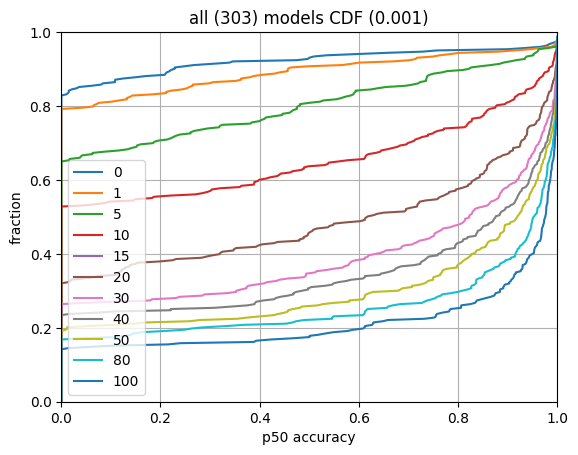

In [12]:
plotCDF(is_species = False, col="p50")

**Observations**
1. For 10 changepoints, approximately, 35% of models have a p10 accuracy of 0.8, and 30% of the models have a p10 accuracy of 0.9.
2. Accuracies for models are generally lower than those for species since a model combines many species and we are considering the tail of the distribution.
3. The other observations about species apply to models.

In [13]:
len(DF["system_id"].unique())

255

## Oscillating vs. Non-Oscillating Models

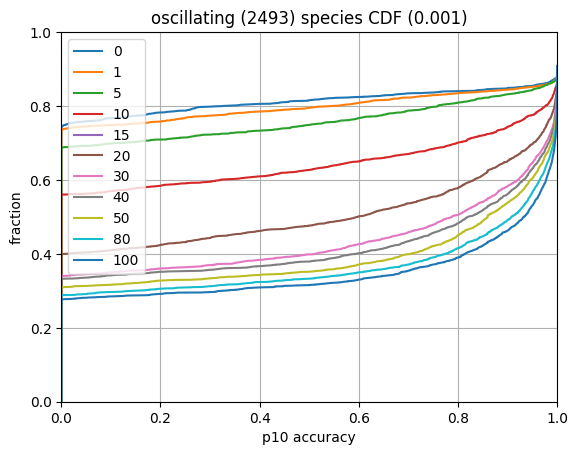

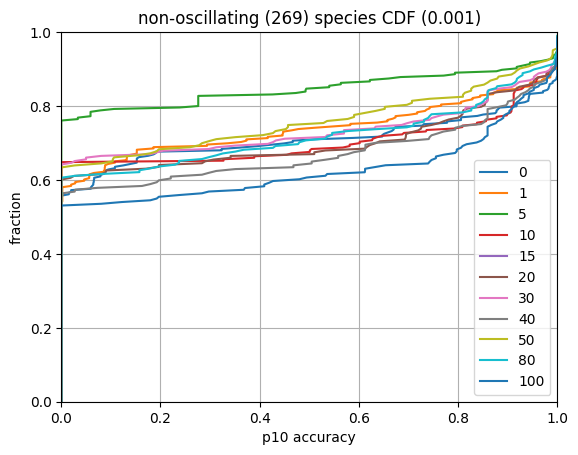

In [14]:
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=False)
plt.figure()
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=True)